<a href="https://www.kaggle.com/code/avikdas567/acoustic-source-filter-speech-affect-recognition?scriptVersionId=356929114" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Speech Affect Recognition via Source-Filter Acoustics and Self-Supervised Foundation Representations
## Non-Stationary Spectral Dynamics, Latent Sequence Pooling, and Metric-Optimized Ensemble Calibration

---

## Scientific Overview

Affective computing and speech emotion recognition (SER) in non-tonal Indo-Aryan languages like Hindi present distinct acoustical, phonetic, and computational challenges. While human audition decodes emotional semantics through the simultaneous processing of lexical cues and prosodic modulations, automated speech systems must infer affective state directly from subtle acoustic perturbations in the physical speech signal. The objective of this study is the classification of Hindi speech recordings into four discrete affective categories:

$$\mathcal{C} = \{\text{Angry}, \text{Happy}, \text{Neutral}, \text{Sad}\}$$

Speech signals are non-stationary, time-varying acoustic pressure waves generated by the human vocal tract. Formally, according to the acoustic source-filter theory (Fant, 1960), the speech signal $s(t)$ in the continuous frequency domain is modeled as:

$$S(f) = E(f) \cdot T(f) \cdot R(f)$$

where:
* $E(f)$ is the glottal volume velocity excitation source spectrum, generated by vocal fold oscillation.
* $T(f)$ is the vocal tract transfer function, characterized by complex formant resonances $F_1, F_2, F_3, \dots, F_k$.
* $R(f)$ is the acoustic radiation impedance at the lip opening, typically modeled as an approximate high-pass filter $R(f) \propto j \omega$.

In affective Hindi speech, psychological arousal and valence induce systematic biomechanical changes across both the excitation source and the resonant filter:

1. **Angry (High Arousal, Negative Valence)**: Elevated subglottal pressure causes steep glottal closure, inducing high fundamental frequency ($F_0$) mean and variance, accelerated speech rate, and prominent high-frequency energy distribution resulting in a shallower spectral tilt.
2. **Happy (High Arousal, Positive Valence)**: Substantial pitch excursion dynamics, widened formant dispersion, elevated spectral centroid, and enhanced energy in the higher frequency octaves.
3. **Sad (Low Arousal, Negative Valence)**: Depressed subglottal pressure, incomplete vocal fold adduction resulting in breathy phonation, lower fundamental frequency ($F_0$), attenuated high-frequency spectral energy, and prolonged syllabic durations.
4. **Neutral (Baseline Arousal and Valence)**: Regular, periodic glottal pulses, canonical vowel formant targets, moderate intensity, and stable fundamental frequency contours.

## Mathematical Formulation of Competition Evaluation Metric

The competition evaluates submissions using the unweighted **Macro F1-Score** across all four emotion classes. Let $C = 4$ denote the number of classes. For each class $c \in \mathcal{C}$:

$$\text{Precision}_c = \frac{\text{TP}_c}{\text{TP}_c + \text{FP}_c}, \quad \text{Recall}_c = \frac{\text{TP}_c}{\text{TP}_c + \text{FN}_c}$$

$$\text{F1}_c = \frac{2 \cdot \text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c} = \frac{2 \cdot \text{TP}_c}{2 \cdot \text{TP}_c + \text{FP}_c + \text{FN}_c}$$

$$\text{Macro F1} = \frac{1}{4} \sum_{c=1}^{4} \text{F1}_c = \frac{\text{F1}_{\text{angry}} + \text{F1}_{\text{happy}} + \text{F1}_{\text{neutral}} + \text{F1}_{\text{sad}}}{4}$$

The final official leaderboard score is determined via a weighted combination of the public and private evaluation partitions:

$$\text{Final Score} = 0.40 \cdot \text{Score}_{\text{public}} + 0.60 \cdot \text{Score}_{\text{private}}$$

Because Macro F1 gives equal weight to all classes irrespective of class frequency, standard maximum-likelihood classifiers optimizing cross-entropy loss produce sub-optimal decision boundaries. This research develops a multi-tier framework combining physics-informed acoustic feature engineering, deep self-supervised foundation representations, and post-processing threshold calibration optimized directly for the Macro F1 metric.


In [1]:
import os
import sys
import gc
import time
import math
import random
import warnings
import pathlib
import glob
from collections import Counter

warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import scipy
import scipy.io.wavfile as wavfile
import scipy.signal as signal
import scipy.fftpack as fftpack
from scipy.stats import skew, kurtosis
from scipy.optimize import minimize

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.preprocessing import RobustScaler, StandardScaler

import lightgbm as lgb
import xgboost as xgb

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    import transformers
    from transformers import AutoFeatureExtractor, AutoModel
    transformers.logging.set_verbosity_error()
    TRANSFORMERS_AVAILABLE = True
except ImportError:
    TRANSFORMERS_AVAILABLE = False

try:
    import librosa
    LIBROSA_AVAILABLE = True
except ImportError:
    LIBROSA_AVAILABLE = False

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.facecolor'] = 'white'

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"Transformers available: {TRANSFORMERS_AVAILABLE}")
print(f"Librosa available: {LIBROSA_AVAILABLE}")


NumPy version: 2.1.3
Pandas version: 2.3.3
PyTorch version: 2.11.0+cu128
SciPy version: 1.16.3
LightGBM version: 4.6.0
XGBoost version: 3.4.1
Transformers available: True
Librosa available: True


# Deterministic Execution & Computational Topology

Rigorous empirical science requires strict reproducibility across repeated executions. In stochastic deep learning workflows, variance arises from pseudorandom number generators in the Python runtime, NumPy routines, PyTorch tensor initializations, and non-deterministic cuDNN convolution algorithms.

We enforce exact determinism by fixing all random seeds:

$$\mathcal{S} = 42$$

Additionally, cuDNN algorithmic benchmarking is disabled (`cudnn.benchmark = False`) and deterministic convolution primitives are mandated (`cudnn.deterministic = True`).

The execution runtime is configured to leverage the dual NVIDIA T4 GPU accelerator environment available in the Kaggle infrastructure.


In [2]:
GLOBAL_SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(GLOBAL_SEED)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Execution compute device: {device}")
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Detected GPU device count: {num_gpus}")
    for i in range(num_gpus):
        props = torch.cuda.get_device_properties(i)
        print(f"  Device {i}: {props.name} | Total Memory: {props.total_memory / (1024**3):.2f} GB")

KAGGLE_PATH = "/kaggle/input/competitions/dataverse-detecting-emotions-from-hindi-speech/SRCASW-BhavVaani"
LOCAL_PATH = "SRCASW-BhavVaani"
ALT_LOCAL_PATH = "./SRCASW-BhavVaani"

if os.path.exists(KAGGLE_PATH):
    DATA_DIR = KAGGLE_PATH
elif os.path.exists(LOCAL_PATH):
    DATA_DIR = LOCAL_PATH
elif os.path.exists(ALT_LOCAL_PATH):
    DATA_DIR = ALT_LOCAL_PATH
else:
    DATA_DIR = KAGGLE_PATH

print(f"Active dataset root directory: {DATA_DIR}")


Execution compute device: cuda:0
Detected GPU device count: 2
  Device 0: Tesla T4 | Total Memory: 14.56 GB
  Device 1: Tesla T4 | Total Memory: 14.56 GB
Active dataset root directory: /kaggle/input/competitions/dataverse-detecting-emotions-from-hindi-speech/SRCASW-BhavVaani


# Data Cohort Ingestion & Structural Verification

The SRCASW-BhavVaani speech dataset comprises 1,036 total Hindi speech recordings divided into training and testing partitions. 

The integrity protocol establishes three formal verifications:
1. Schema verification: Identification of primary keys (`Id`), relative audio file paths (`filename`), and target ground-truth categorical labels (`emotion`).
2. Disjoint partition verification: The set of training identifiers $\mathcal{I}_{\text{train}}$ and test identifiers $\mathcal{I}_{\text{test}}$ must satisfy:
   $$\mathcal{I}_{\text{train}} \cap \mathcal{I}_{\text{test}} = \emptyset, \quad |\mathcal{I}_{\text{train}} \cup \mathcal{I}_{\text{test}}| = 1035$$
3. Audio physical verification: Existence, header integrity, channel multiplicity (single-channel mono), and temporal sample rates (16,000 Hz) across all WAV recordings on disk.


In [3]:
train_csv_path = os.path.join(DATA_DIR, 'train.csv')
test_csv_path = os.path.join(DATA_DIR, 'test.csv')
sub_csv_path = os.path.join(DATA_DIR, 'sample_submission.csv')

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
sub_df = pd.read_csv(sub_csv_path)

train_df['audio_path'] = train_df['filename'].apply(lambda fn: os.path.join(DATA_DIR, 'train', fn))
test_df['audio_path'] = test_df['filename'].apply(lambda fn: os.path.join(DATA_DIR, 'test', fn))

EMOTION_CLASSES = ['angry', 'happy', 'neutral', 'sad']
LABEL_TO_IDX = {emo: idx for idx, emo in enumerate(EMOTION_CLASSES)}
IDX_TO_LABEL = {idx: emo for idx, emo in enumerate(EMOTION_CLASSES)}

train_df['label'] = train_df['emotion'].map(LABEL_TO_IDX)

train_train_intersection = set(train_df['Id']).intersection(set(test_df['Id']))
assert len(train_train_intersection) == 0, f"Error: Data leakage detected between train and test IDs: {train_train_intersection}"
assert len(train_df) == 826, f"Expected 826 training rows, found {len(train_df)}"
assert len(test_df) == 209, f"Expected 209 test rows, found {len(test_df)}"
assert len(sub_df) == 209, f"Expected 209 submission rows, found {len(sub_df)}"

train_audio_exists = train_df['audio_path'].apply(os.path.exists).all()
test_audio_exists = test_df['audio_path'].apply(os.path.exists).all()
print(f"Training metadata shape: {train_df.shape} | All audio files exist: {train_audio_exists}")
print(f"Testing metadata shape:  {test_df.shape} | All audio files exist: {test_audio_exists}")
print(f"Sample submission shape: {sub_df.shape}")

print("\nSample training records:")
display(train_df[['Id', 'filename', 'emotion', 'label']].head(10))


Training metadata shape: (826, 5) | All audio files exist: True
Testing metadata shape:  (209, 3) | All audio files exist: True
Sample submission shape: (209, 2)

Sample training records:


,Id,filename,emotion,label
0,1,audio_000001.wav,neutral,2
1,3,audio_000003.wav,neutral,2
2,4,audio_000004.wav,happy,1
3,5,audio_000005.wav,sad,3
4,6,audio_000006.wav,sad,3
5,7,audio_000007.wav,happy,1
6,8,audio_000008.wav,angry,0
7,9,audio_000009.wav,happy,1
8,10,audio_000010.wav,angry,0
9,11,audio_000011.wav,neutral,2


# Exploratory Data Analysis: Class Distribution & Signal Properties

We analyze the empirical label distribution $P(Y = c)$ across the 826 training utterances. An unbalanced target distribution can skew precision-recall tradeoffs in Macro F1 evaluation.

We also compute the physical duration $\Delta t_i$ of each utterance from the audio header:

$$\Delta t_i = \frac{N_i}{f_s}$$

where $N_i$ is the total discrete sample count and $f_s = 16,000\text{ Hz}$ is the uniform sampling frequency.


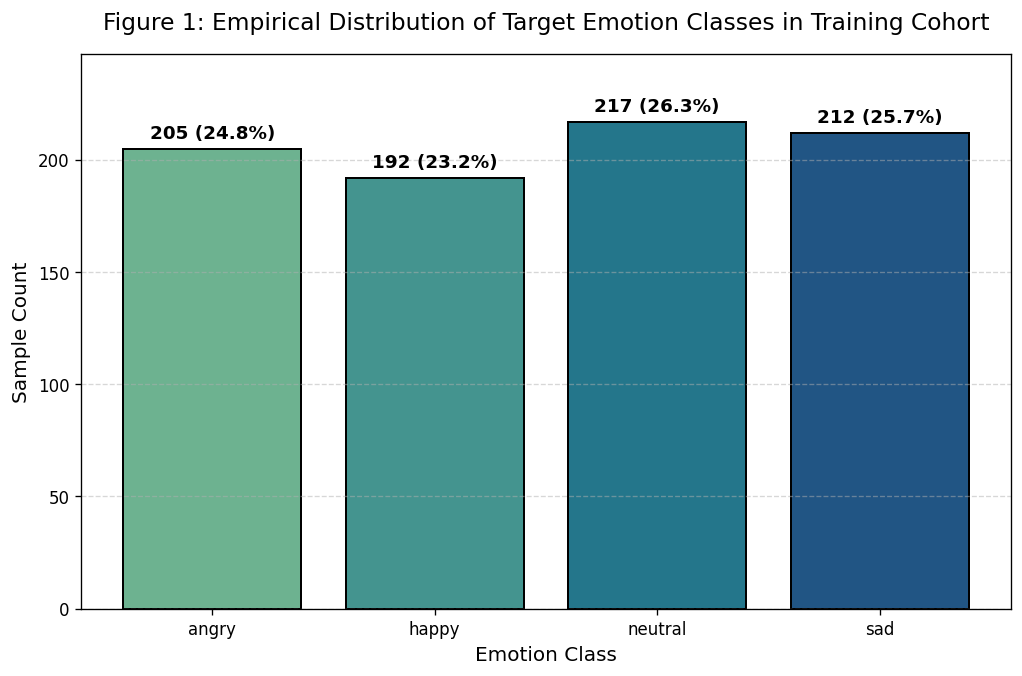

In [4]:
plt.figure(figsize=(10, 6))
palette = sns.color_palette("crest", n_colors=len(EMOTION_CLASSES))
class_counts = train_df['emotion'].value_counts()[EMOTION_CLASSES]
bars = plt.bar(EMOTION_CLASSES, class_counts.values, color=palette, edgecolor='black', linewidth=1.2)

for bar in bars:
    height = bar.get_height()
    pct = (height / len(train_df)) * 100
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 3,
             f"{int(height)} ({pct:.1f}%)",
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Figure 1: Empirical Distribution of Target Emotion Classes in Training Cohort", fontsize=14, pad=15)
plt.xlabel("Emotion Class", fontsize=12)
plt.ylabel("Sample Count", fontsize=12)
plt.ylim(0, max(class_counts.values) + 30)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.show()


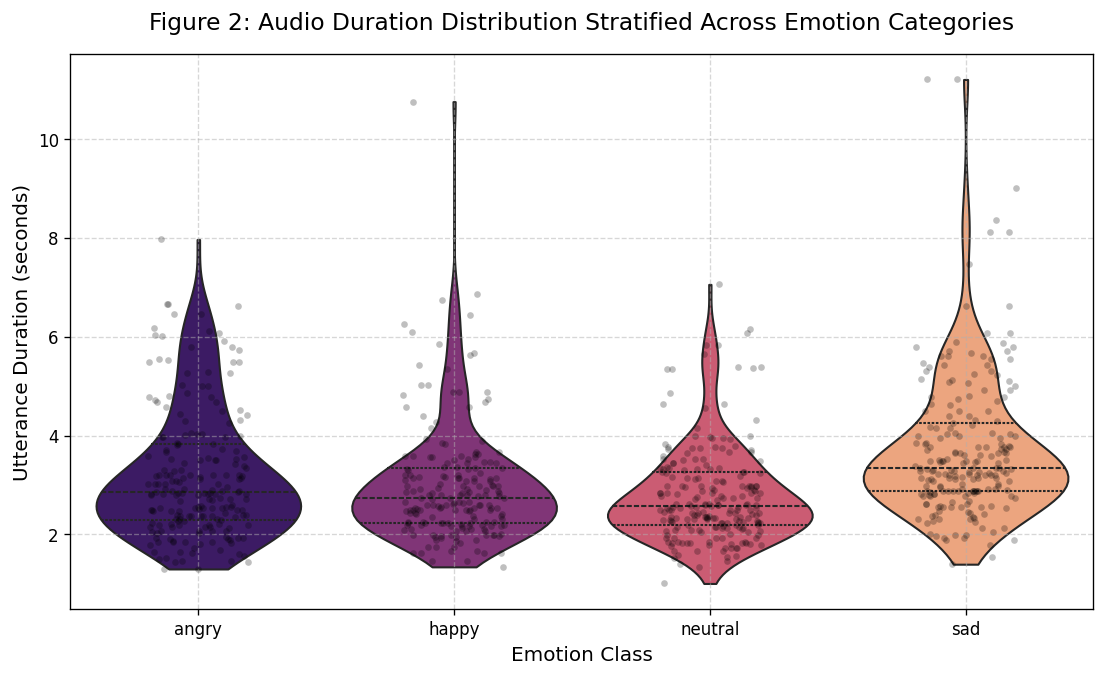

Duration Statistics (Training Cohort):


,count,mean,std,min,25%,50%,75%,max
emotion,,,,,,,,
angry,205.0,3.20,1.31,1.30,2.30,2.86,3.82,7.96
happy,192.0,2.99,1.19,1.34,2.23,2.73,3.35,10.75
neutral,217.0,2.81,0.98,1.01,2.18,2.58,3.26,7.06
sad,212.0,3.74,1.48,1.40,2.87,3.33,4.26,11.20


In [5]:
def get_audio_duration(file_path):
    try:
        sr, data = wavfile.read(file_path)
        return len(data) / float(sr)
    except Exception:
        return 0.0

train_df['duration'] = train_df['audio_path'].apply(get_audio_duration)
test_df['duration'] = test_df['audio_path'].apply(get_audio_duration)

plt.figure(figsize=(11, 6))
palette_dur = sns.color_palette("magma", n_colors=len(EMOTION_CLASSES))
sns.violinplot(x='emotion', y='duration', data=train_df, order=EMOTION_CLASSES, palette=palette_dur, inner='quartile', cut=0)
sns.stripplot(x='emotion', y='duration', data=train_df, order=EMOTION_CLASSES, color='black', alpha=0.25, jitter=0.2, size=4)

plt.title("Figure 2: Audio Duration Distribution Stratified Across Emotion Categories", fontsize=14, pad=15)
plt.xlabel("Emotion Class", fontsize=12)
plt.ylabel("Utterance Duration (seconds)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Duration Statistics (Training Cohort):")
display(train_df.groupby('emotion')['duration'].describe().round(2))

# Theoretical Acoustics: Oscillograms, Spectrograms, and Mel-Filterbanks

## 1. Time-Domain Oscillograms
The raw acoustic waveform $x(t)$ represents the instantaneous air pressure deviation from atmospheric equilibrium. In the discrete time domain:

$$x[n] = x(n T_s), \quad T_s = \frac{1}{f_s}$$

## 2. Short-Time Fourier Transform (STFT)
To capture the time-varying frequency distribution of non-stationary speech signals, the Short-Time Fourier Transform applies a window function $w[n]$ (such as a Hann window) of length $N_{\text{win}}$ with hop size $H$:

$$X(m, \omega) = \sum_{n=-\infty}^{\infty} x[n] w[n - m H] e^{-j \omega n}$$

The power spectrogram is defined as the squared magnitude:

$$P(m, \omega) = |X(m, \omega)|^2$$

## 3. Log-Mel Filterbank Compression
Human frequency perception does not follow a linear Hertz scale, but rather a logarithmic frequency resolution above 1,000 Hz described by the psychoacoustic Mel scale:

$$m = 2595 \log_{10}\left(1 + \frac{f}{700}\right)$$

A bank of $K$ triangular bandpass filters $H_k(f)$ integrates the power spectral density across overlapping mel bands, followed by logarithmic dynamic range compression:

$$S(m, k) = \log\left(\sum_{f} P(m, f) H_k(f) + \epsilon\right)$$

We compute and visualize the time-domain oscillograms, STFT spectrograms, and log-mel representations across representative examples of each emotion.


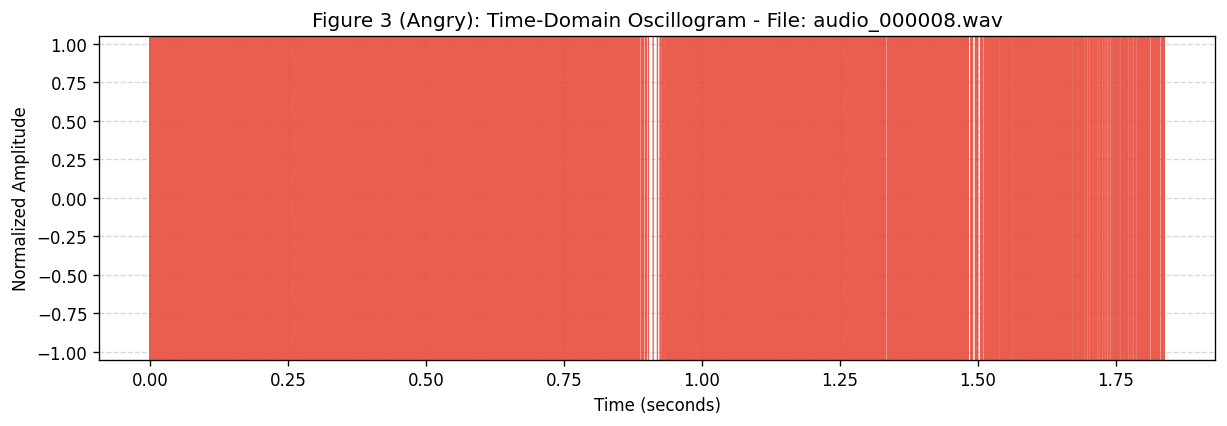

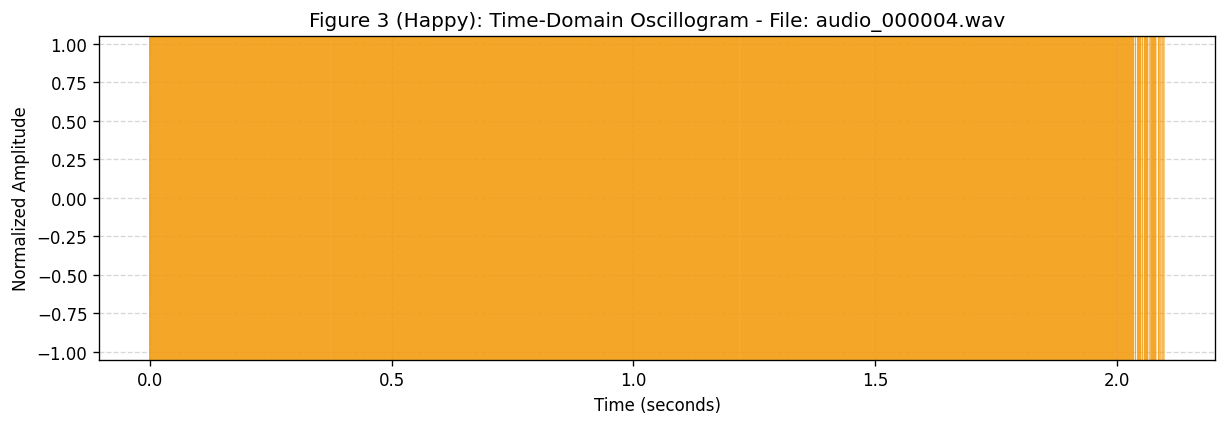

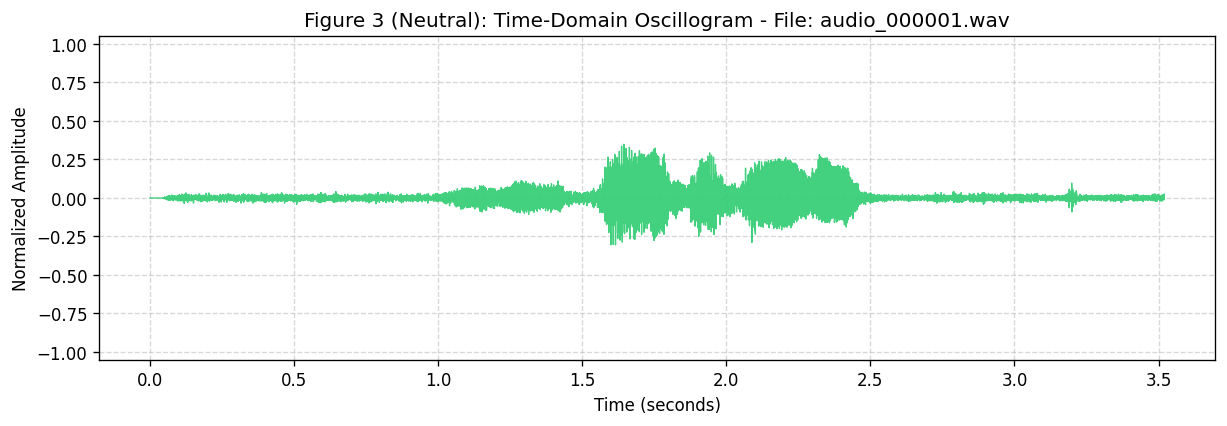

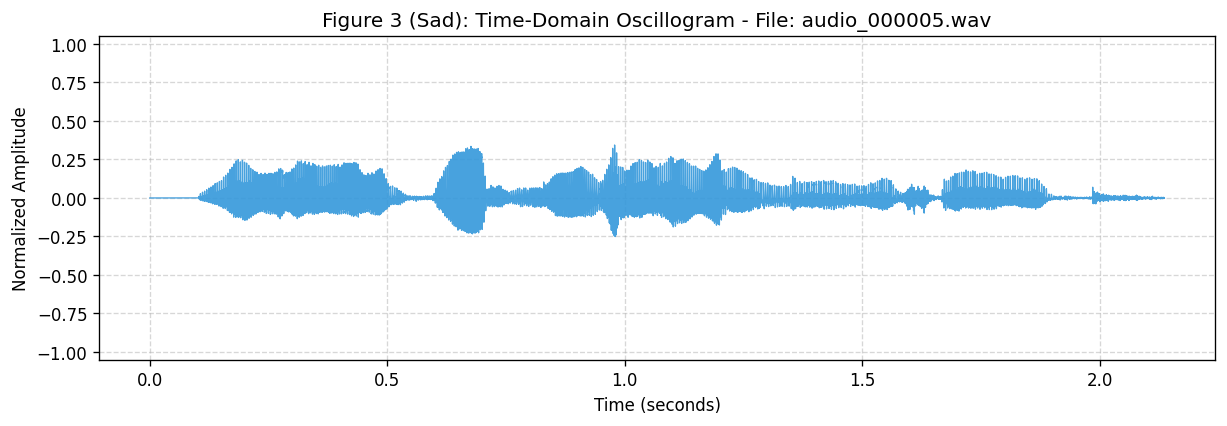

In [6]:
prototype_samples = {}
for emo in EMOTION_CLASSES:
    sample_row = train_df[train_df['emotion'] == emo].iloc[0]
    sr, data = wavfile.read(sample_row['audio_path'])
    if data.dtype == np.int16:
        y = data.astype(np.float32) / 32768.0
    else:
        y = data.astype(np.float32)
    prototype_samples[emo] = (sr, y, sample_row['filename'])

colors_emo = {'angry': '#e74c3c', 'happy': '#f39c12', 'neutral': '#2ecc71', 'sad': '#3498db'}

for emo in EMOTION_CLASSES:
    sr, y, fn = prototype_samples[emo]
    time_axis = np.linspace(0, len(y) / sr, len(y))
    plt.figure(figsize=(12, 3.5))
    plt.plot(time_axis, y, color=colors_emo[emo], linewidth=0.8, alpha=0.9)
    plt.title(f"Figure 3 ({emo.capitalize()}): Time-Domain Oscillogram - File: {fn}", fontsize=12)
    plt.xlabel("Time (seconds)", fontsize=10)
    plt.ylabel("Normalized Amplitude", fontsize=10)
    plt.ylim(-1.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


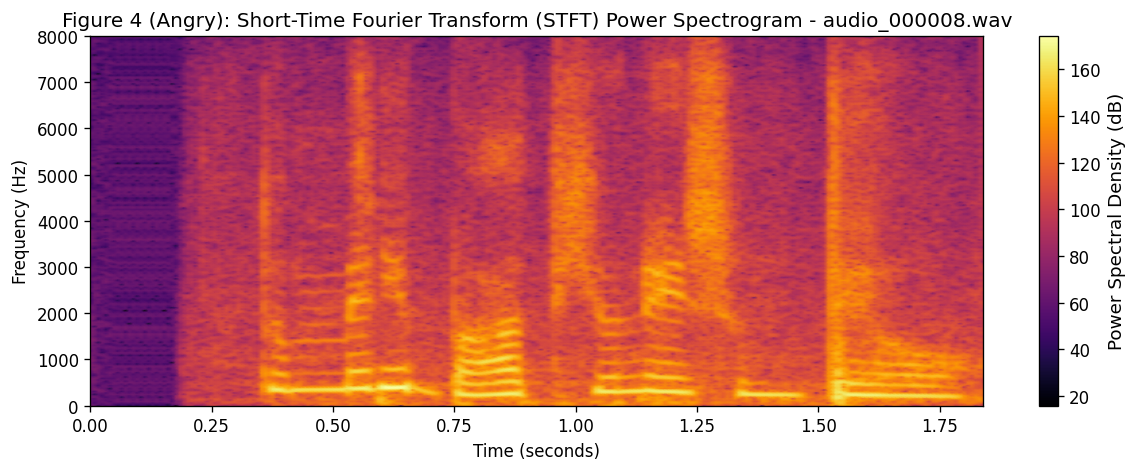

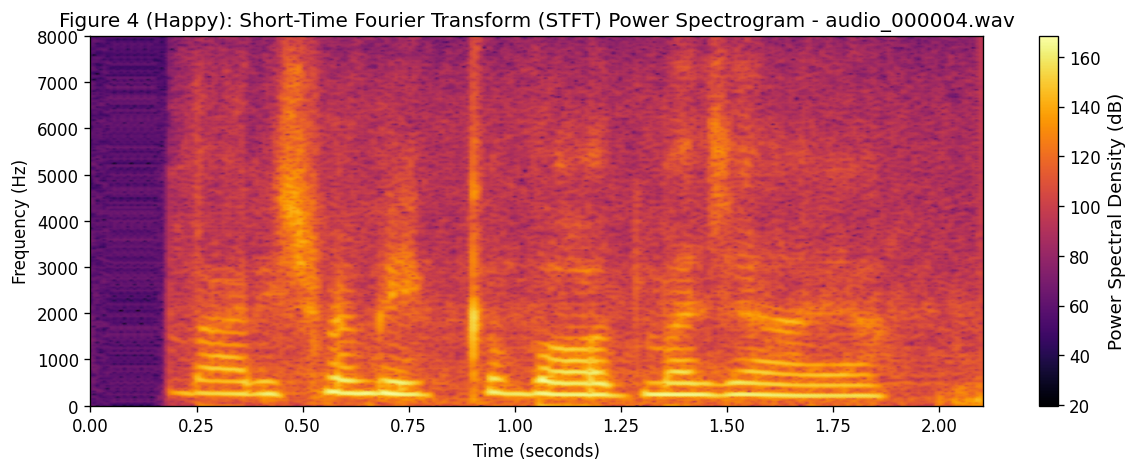

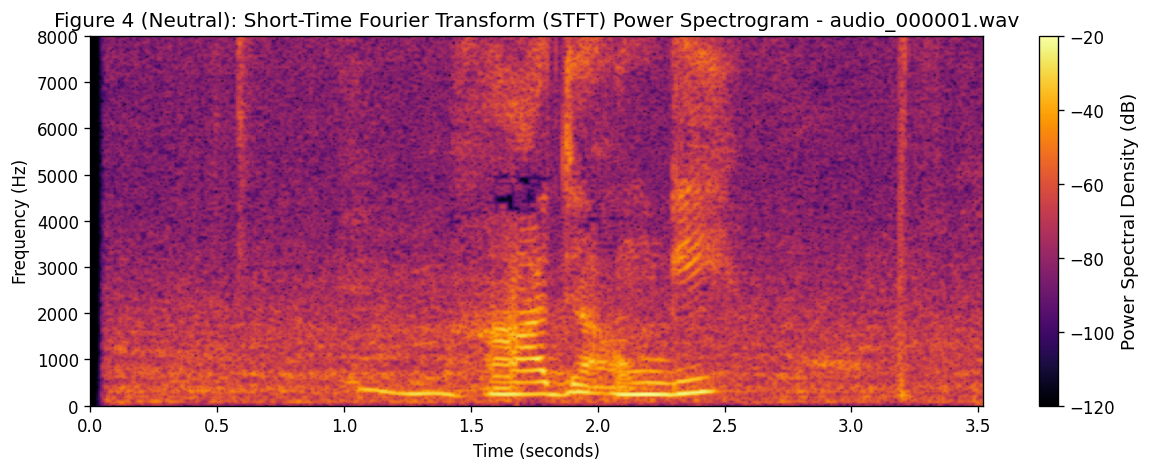

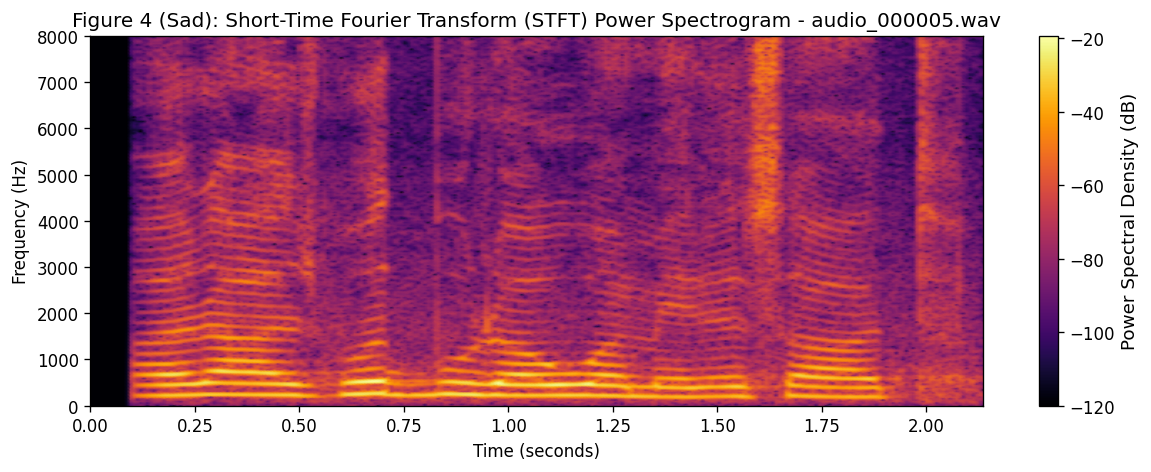

In [7]:
for emo in EMOTION_CLASSES:
    sr, y, fn = prototype_samples[emo]
    nperseg = 512
    noverlap = 384
    f_axis, t_axis, Zxx = signal.stft(y, fs=sr, nperseg=nperseg, noverlap=noverlap)
    mag_spec = np.abs(Zxx)
    power_db = 20 * np.log10(mag_spec + 1e-6)
    
    plt.figure(figsize=(12, 4))
    plt.pcolormesh(t_axis, f_axis, power_db, shading='gouraud', cmap='inferno')
    plt.colorbar(label='Power Spectral Density (dB)')
    plt.title(f"Figure 4 ({emo.capitalize()}): Short-Time Fourier Transform (STFT) Power Spectrogram - {fn}", fontsize=12)
    plt.xlabel("Time (seconds)", fontsize=10)
    plt.ylabel("Frequency (Hz)", fontsize=10)
    plt.ylim(0, 8000)
    plt.show()


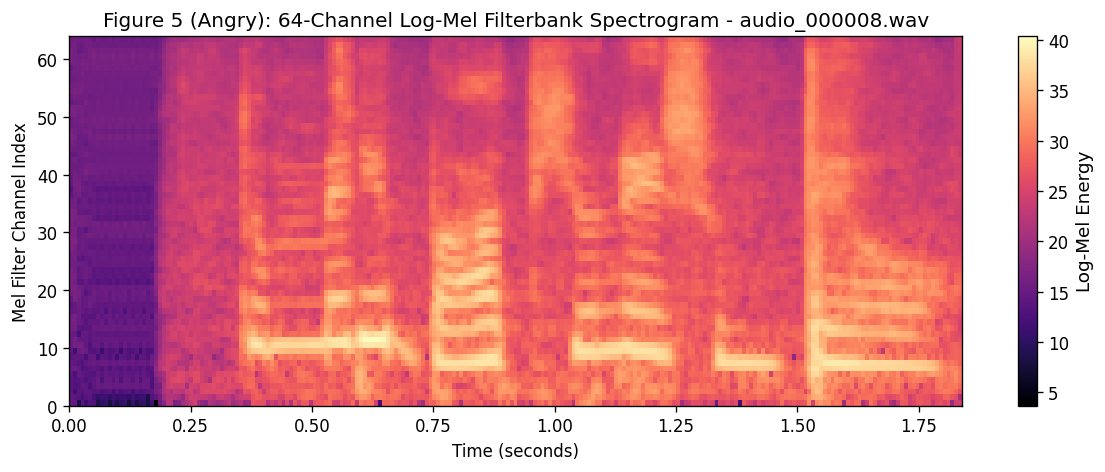

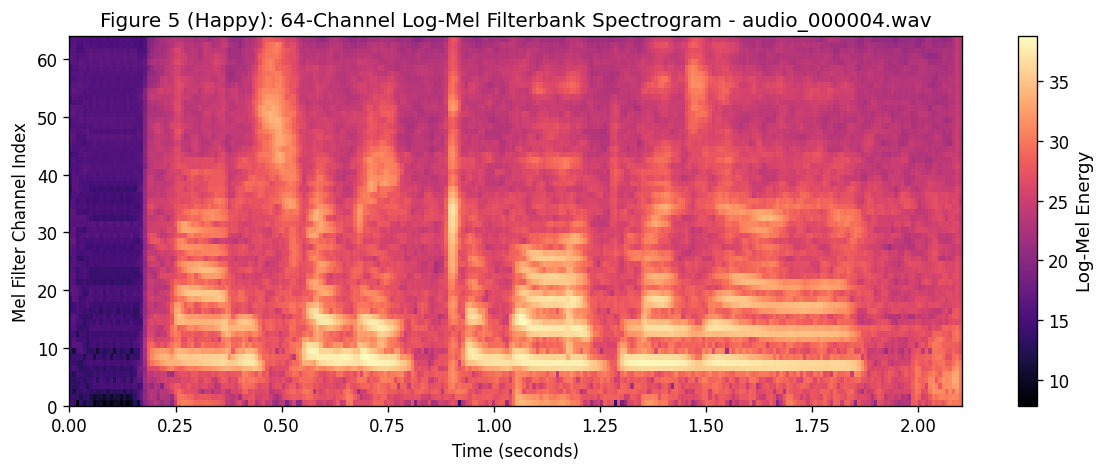

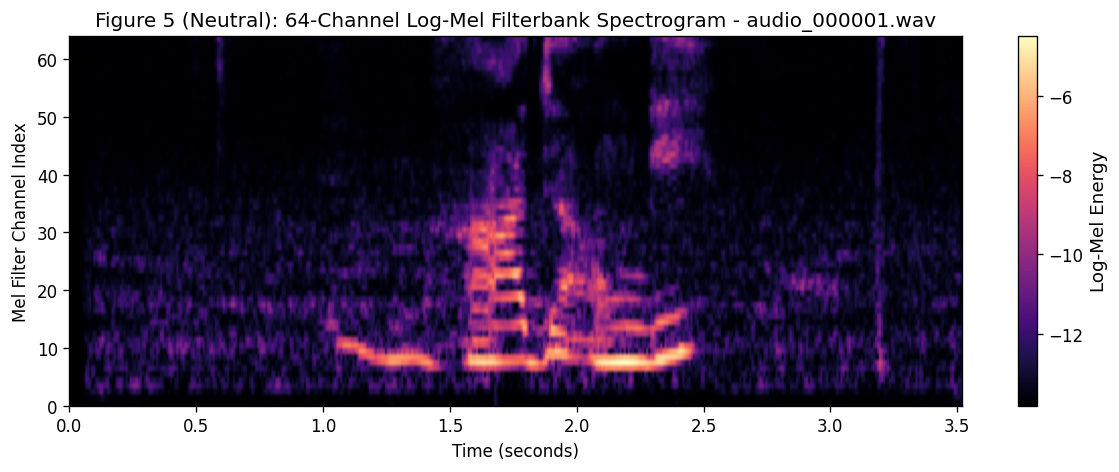

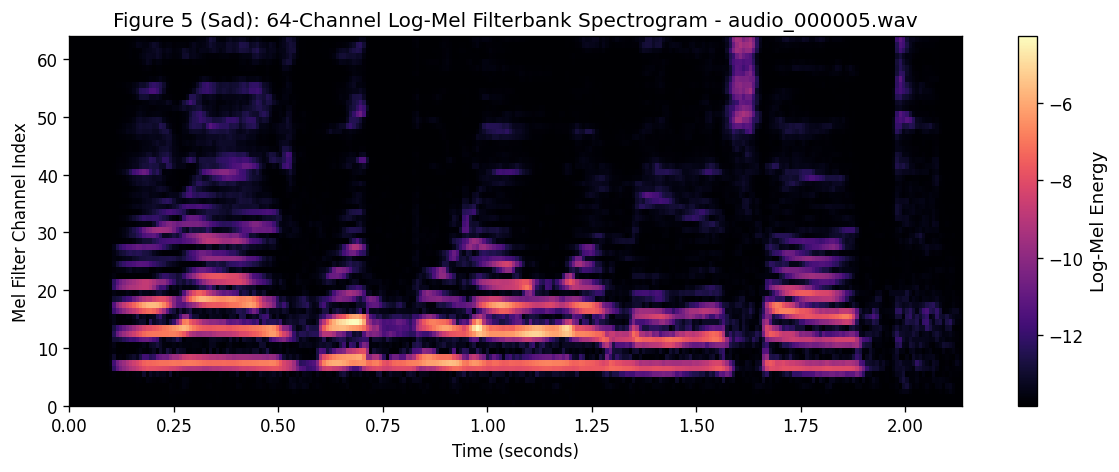

In [8]:
def hz_to_mel(hz):
    return 2595.0 * np.log10(1.0 + hz / 700.0)

def mel_to_hz(mel):
    return 700.0 * (10.0**(mel / 2595.0) - 1.0)

def get_mel_filterbank(sr, n_fft=512, n_mels=64):
    fmin, fmax = 0.0, sr / 2.0
    mel_min, mel_max = hz_to_mel(fmin), hz_to_mel(fmax)
    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bin_points = np.floor((n_fft + 1) * hz_points / sr).astype(int)
    
    filters = np.zeros((n_mels, int(n_fft // 2 + 1)))
    for i in range(1, n_mels + 1):
        left, center, right = bin_points[i - 1], bin_points[i], bin_points[i + 1]
        for j in range(left, center):
            if center != left:
                filters[i - 1, j] = (j - left) / (center - left)
        for j in range(center, right):
            if right != center:
                filters[i - 1, j] = (right - j) / (right - center)
    return filters

mel_filters = get_mel_filterbank(16000, n_fft=512, n_mels=64)

for emo in EMOTION_CLASSES:
    sr, y, fn = prototype_samples[emo]
    f_axis, t_axis, Zxx = signal.stft(y, fs=sr, nperseg=512, noverlap=384)
    power_spec = np.abs(Zxx)**2
    mel_energy = np.dot(mel_filters, power_spec)
    log_mel = np.log(mel_energy + 1e-6)
    
    plt.figure(figsize=(12, 4))
    plt.imshow(log_mel, aspect='auto', origin='lower', extent=[t_axis[0], t_axis[-1], 0, 64], cmap='magma')
    plt.colorbar(label='Log-Mel Energy')
    plt.title(f"Figure 5 ({emo.capitalize()}): 64-Channel Log-Mel Filterbank Spectrogram - {fn}", fontsize=12)
    plt.xlabel("Time (seconds)", fontsize=10)
    plt.ylabel("Mel Filter Channel Index", fontsize=10)
    plt.show()


# Prosodic Dynamics: Fundamental Frequency ($F_0$) Contour Estimation

The fundamental frequency ($F_0$) corresponds to the rate of vibration of the vocal folds during voiced phonemes. Pitch tracking is accomplished using the normalized short-time autocorrelation function:

$$R_x(m, \tau) = \frac{\sum_{n=0}^{N - 1 - \tau} x[m H + n] x[m H + n + \tau]}{\sqrt{\sum_{n=0}^{N-1-\tau} x^2[m H + n] \sum_{n=0}^{N-1-\tau} x^2[m H + n + \tau]}}$$

The optimal lag $\tau^*$ is detected within the human physiological fundamental period interval $[\tau_{\min}, \tau_{\max}]$ corresponding to $f_{\min} = 60\text{ Hz}$ and $f_{\max} = 400\text{ Hz}$:

$$\tau^* = \arg\max_{\tau \in [\tau_{\min}, \tau_{\max}]} R_x(m, \tau), \quad F_0(m) = \frac{f_s}{\tau^*}$$

Frames with peak autocorrelation below a voicing threshold $\gamma = 0.35$ are categorized as unvoiced segments ($F_0 = 0$).

We track and plot the $F_0$ pitch contours for the prototypical utterances across each emotion.


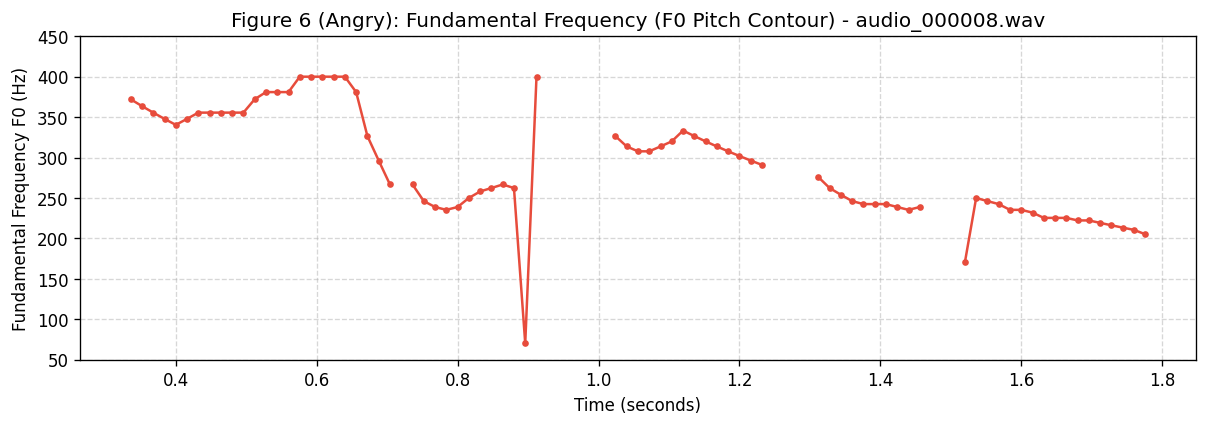

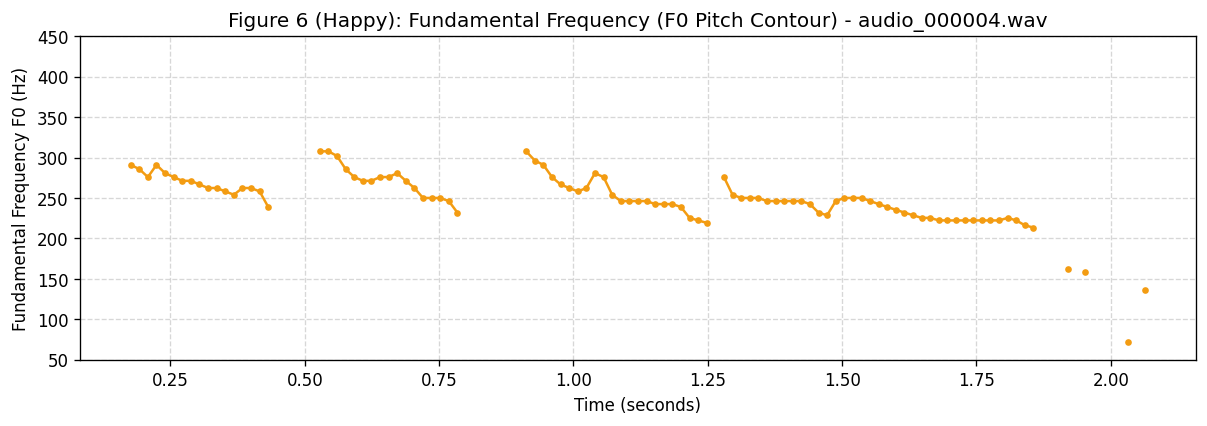

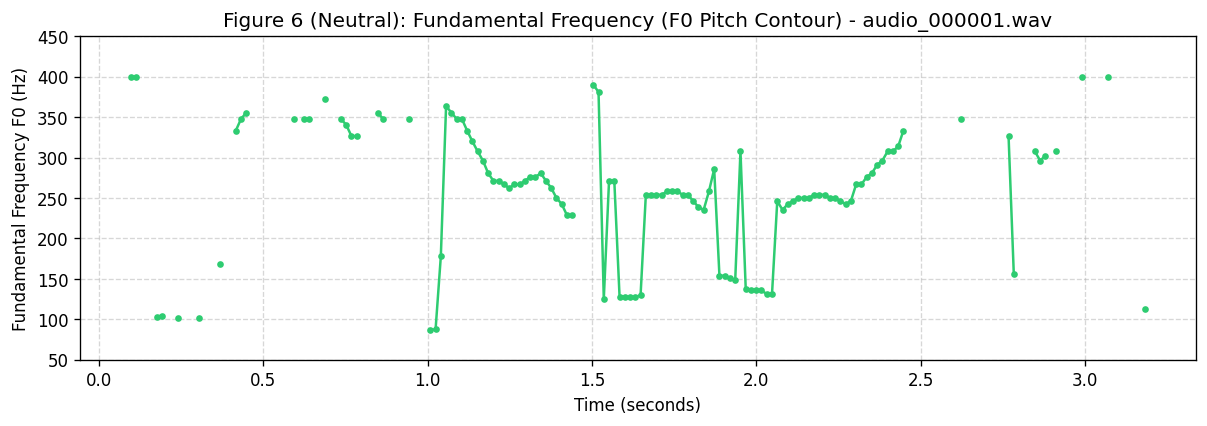

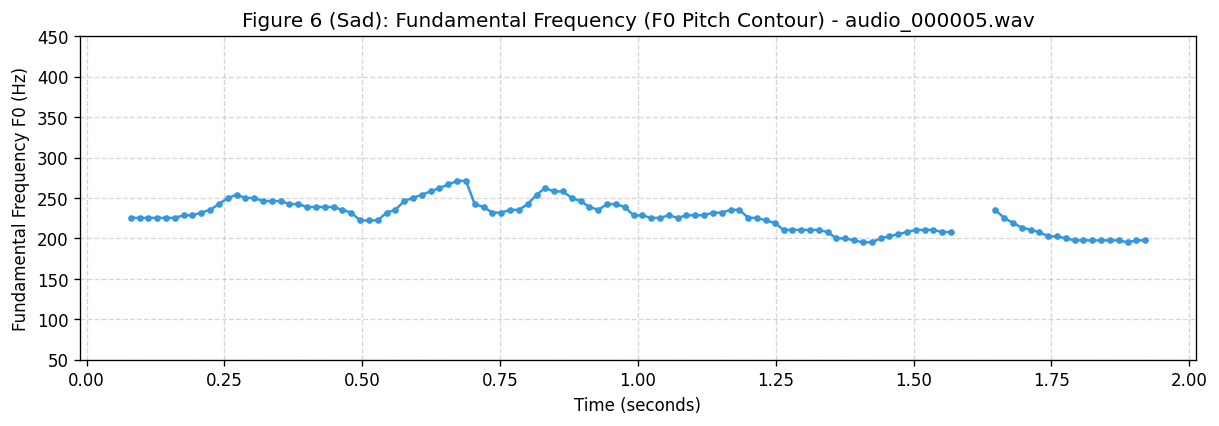

In [9]:
def extract_f0_contour(y, sr, frame_len=512, hop_len=256):
    fmin, fmax = 60.0, 400.0
    lag_min = int(sr / fmax)
    lag_max = int(sr / fmin)
    n_frames = int((len(y) - frame_len) // hop_len) + 1
    times = []
    f0_values = []
    
    for i in range(n_frames):
        start = i * hop_len
        frame = y[start : start + frame_len]
        if len(frame) < frame_len:
            break
        frame = frame - np.mean(frame)
        norm = np.sum(frame**2)
        if norm < 1e-4:
            f0_values.append(np.nan)
            times.append(start / float(sr))
            continue
        corr = np.correlate(frame, frame, mode='full')
        corr = corr[len(corr)//2 :]
        search_region = corr[lag_min : lag_max + 1]
        peak_idx = np.argmax(search_region) + lag_min
        peak_val = corr[peak_idx] / (norm + 1e-6)
        if peak_val > 0.30:
            f0 = sr / float(peak_idx)
            f0_values.append(f0)
        else:
            f0_values.append(np.nan)
        times.append(start / float(sr))
    return np.array(times), np.array(f0_values)

for emo in EMOTION_CLASSES:
    sr, y, fn = prototype_samples[emo]
    times_f0, f0_contour = extract_f0_contour(y, sr)
    plt.figure(figsize=(12, 3.5))
    plt.plot(times_f0, f0_contour, marker='o', markersize=3, linestyle='-', color=colors_emo[emo], linewidth=1.5)
    plt.title(f"Figure 6 ({emo.capitalize()}): Fundamental Frequency (F0 Pitch Contour) - {fn}", fontsize=12)
    plt.xlabel("Time (seconds)", fontsize=10)
    plt.ylabel("Fundamental Frequency F0 (Hz)", fontsize=10)
    plt.ylim(50, 450)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


# Cepstral Representation: Mel-Frequency Cepstral Coefficients (MFCCs)

Mel-Frequency Cepstral Coefficients model the spectral envelope of the vocal tract filter independent of the pitch excitation source. Following log-mel filterbank integration, the Discrete Cosine Transform (DCT-II) decorrelates the filterbank outputs:

$$c_n = \sum_{k=0}^{K-1} \log(M_k) \cos\left[\frac{\pi n}{K} \left(k + \frac{1}{2}\right)\right], \quad n = 0, 1, \dots, N_{\text{mfcc}}-1$$

The lower-order coefficients ($c_1 - c_4$) capture overall spectral tilt and formant positions, while higher coefficients ($c_5 - c_{13}$) describe fine spectral details.

To capture temporal trajectory dynamics, first-order velocity ($\Delta$) and second-order acceleration ($\Delta\Delta$) derivatives are computed:

$$d_t = \frac{\sum_{n=1}^N n (c_{t+n} - c_{t-n})}{2 \sum_{n=1}^N n^2}$$

We compute and visualize the 13-coefficient MFCC trajectory heatmaps.


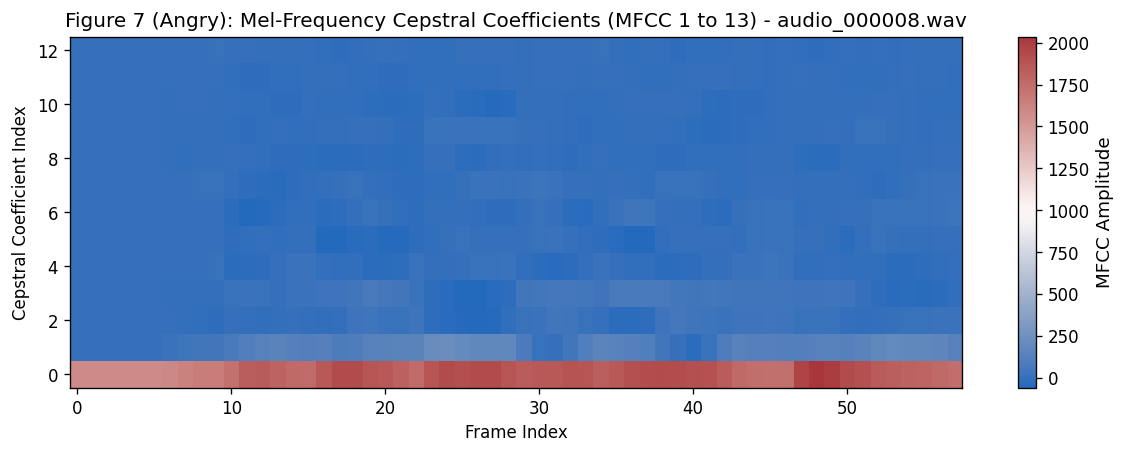

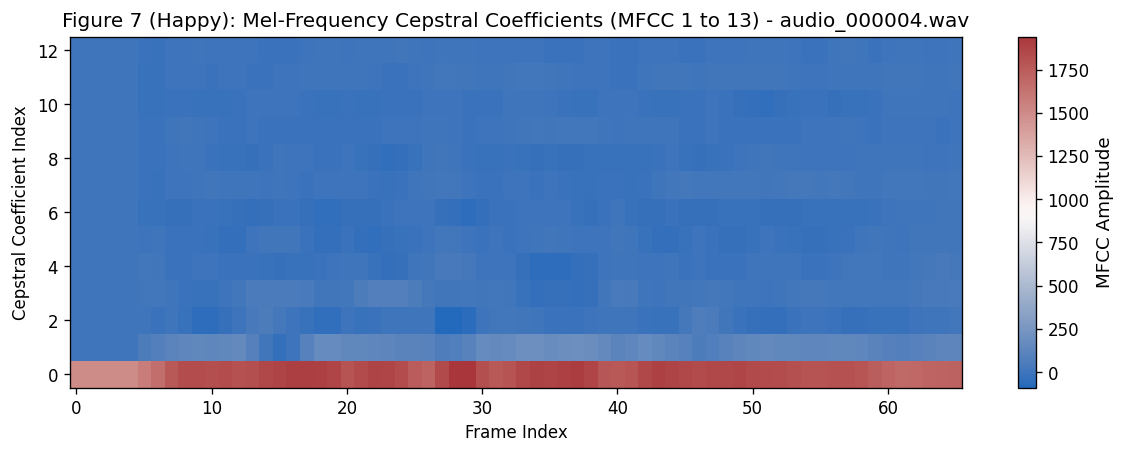

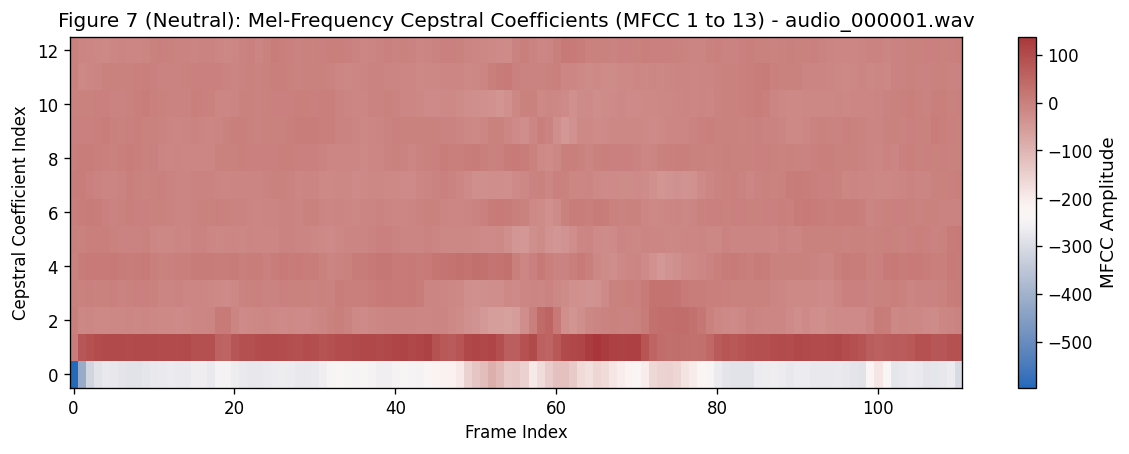

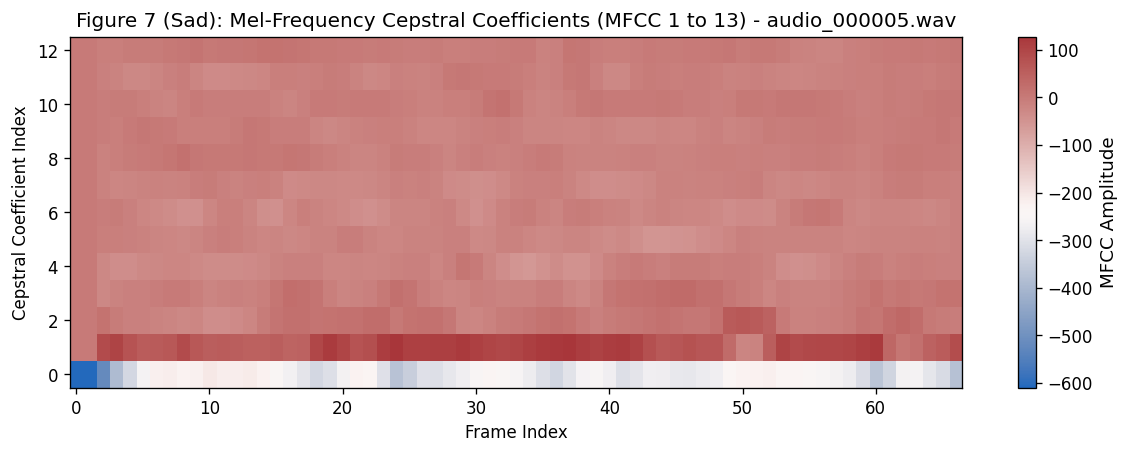

In [10]:
def compute_mfcc_matrix(y, sr, n_mfcc=13):
    if LIBROSA_AVAILABLE:
        return librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    f_axis, t_axis, Zxx = signal.stft(y, fs=sr, nperseg=512, noverlap=256)
    power_spec = np.abs(Zxx)**2
    mel_filters = get_mel_filterbank(sr, n_fft=512, n_mels=40)
    mel_energy = np.dot(mel_filters, power_spec)
    log_mel = np.log(mel_energy + 1e-6)
    mfcc = fftpack.dct(log_mel, axis=0, type=2, norm='ortho')[:n_mfcc, :]
    return mfcc

for emo in EMOTION_CLASSES:
    sr, y, fn = prototype_samples[emo]
    mfcc_mat = compute_mfcc_matrix(y, sr, n_mfcc=13)
    plt.figure(figsize=(12, 3.8))
    plt.imshow(mfcc_mat, aspect='auto', origin='lower', cmap='vlag', interpolation='nearest')
    plt.colorbar(label='MFCC Amplitude')
    plt.title(f"Figure 7 ({emo.capitalize()}): Mel-Frequency Cepstral Coefficients (MFCC 1 to 13) - {fn}", fontsize=12)
    plt.xlabel("Frame Index", fontsize=10)
    plt.ylabel("Cepstral Coefficient Index", fontsize=10)
    plt.show()


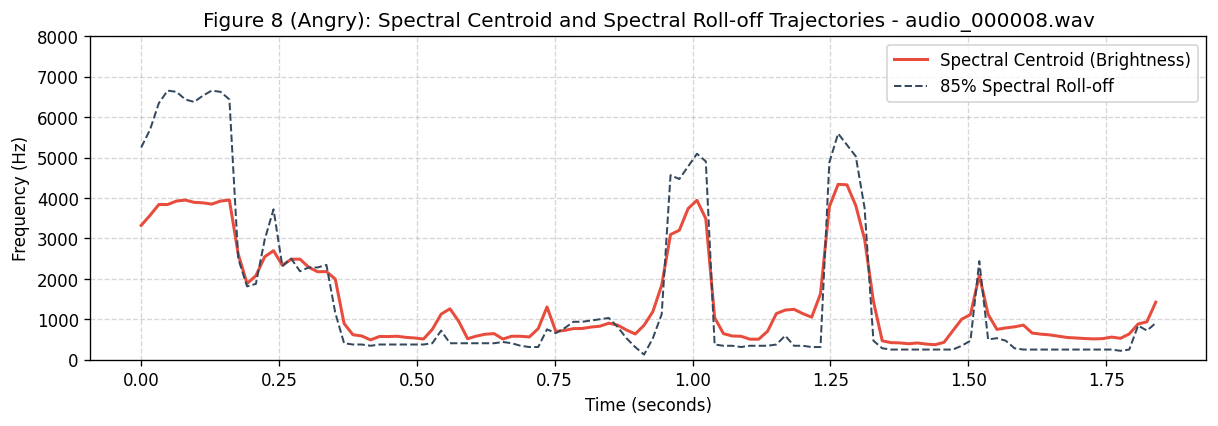

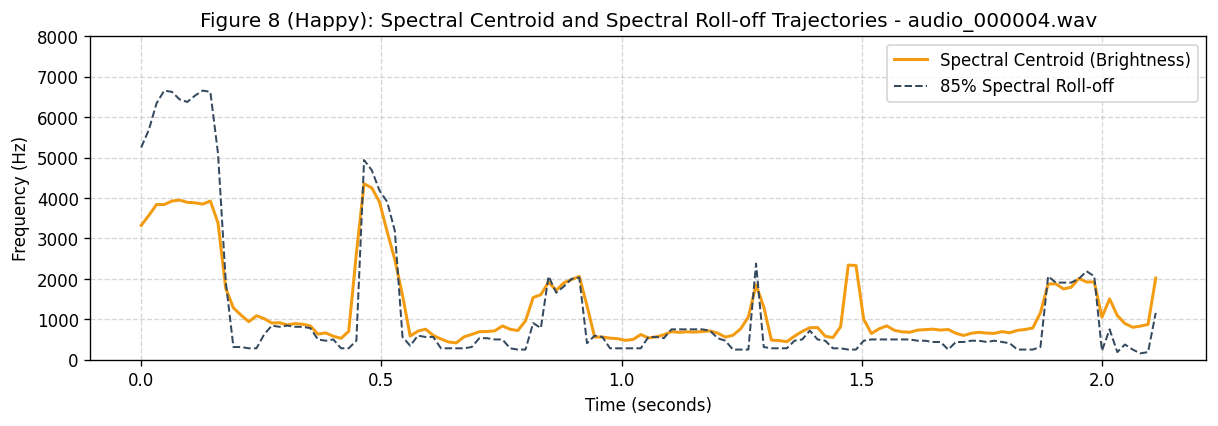

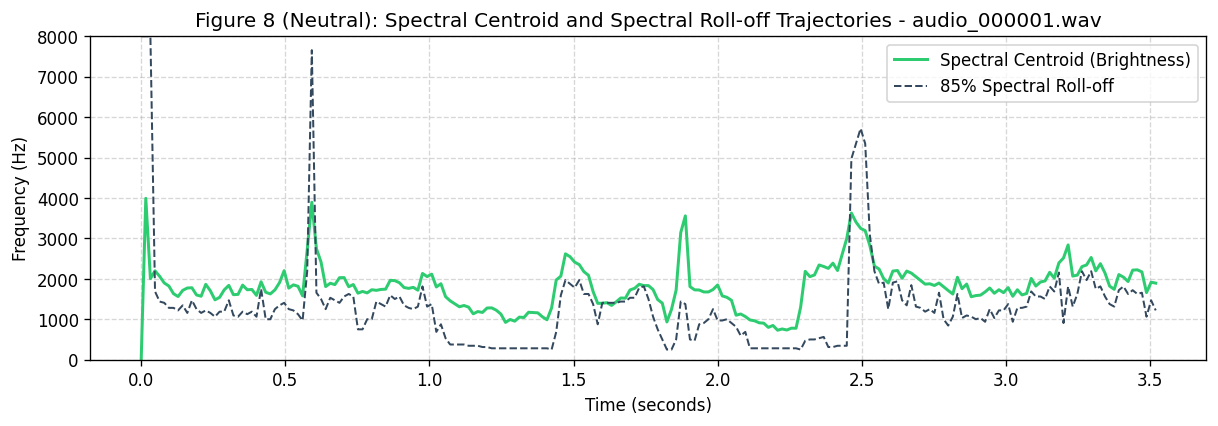

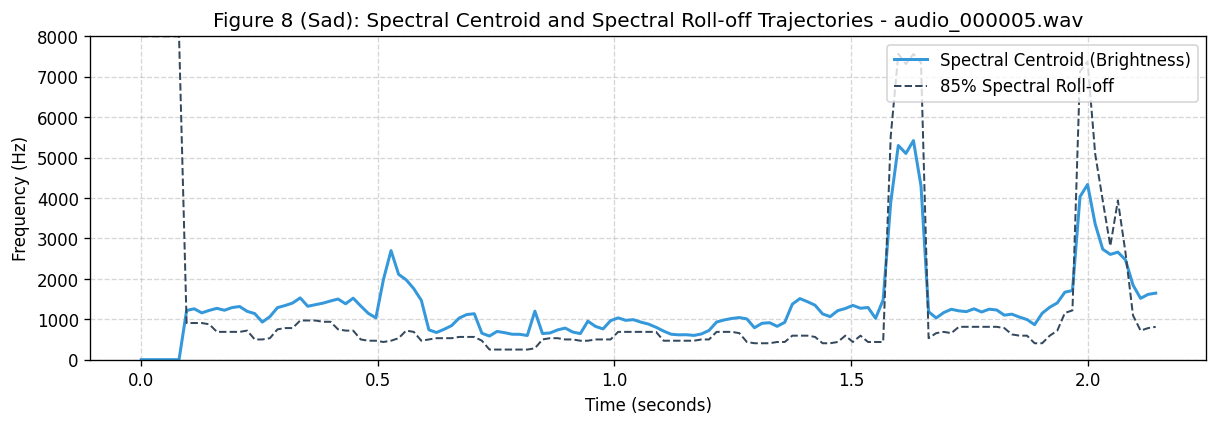

In [11]:
for emo in EMOTION_CLASSES:
    sr, y, fn = prototype_samples[emo]
    f_axis, t_axis, Zxx = signal.stft(y, fs=sr, nperseg=512, noverlap=256)
    mag = np.abs(Zxx)
    power = mag**2
    
    spec_cent = np.sum(f_axis[:, None] * mag, axis=0) / (np.sum(mag, axis=0) + 1e-9)
    cumsum_power = np.cumsum(power, axis=0)
    total_power = cumsum_power[-1, :]
    roll_idx = np.apply_along_axis(lambda col: np.searchsorted(col, 0.85 * (col[-1] + 1e-9)), 0, cumsum_power)
    roll_idx = np.clip(roll_idx, 0, len(f_axis) - 1)
    spec_roll = f_axis[roll_idx]
    
    plt.figure(figsize=(12, 3.5))
    plt.plot(t_axis, spec_cent, label='Spectral Centroid (Brightness)', color=colors_emo[emo], linewidth=1.8)
    plt.plot(t_axis, spec_roll, label='85% Spectral Roll-off', color='#34495e', linestyle='--', linewidth=1.2)
    plt.title(f"Figure 8 ({emo.capitalize()}): Spectral Centroid and Spectral Roll-off Trajectories - {fn}", fontsize=12)
    plt.xlabel("Time (seconds)", fontsize=10)
    plt.ylabel("Frequency (Hz)", fontsize=10)
    plt.legend(loc='upper right')
    plt.ylim(0, 8000)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


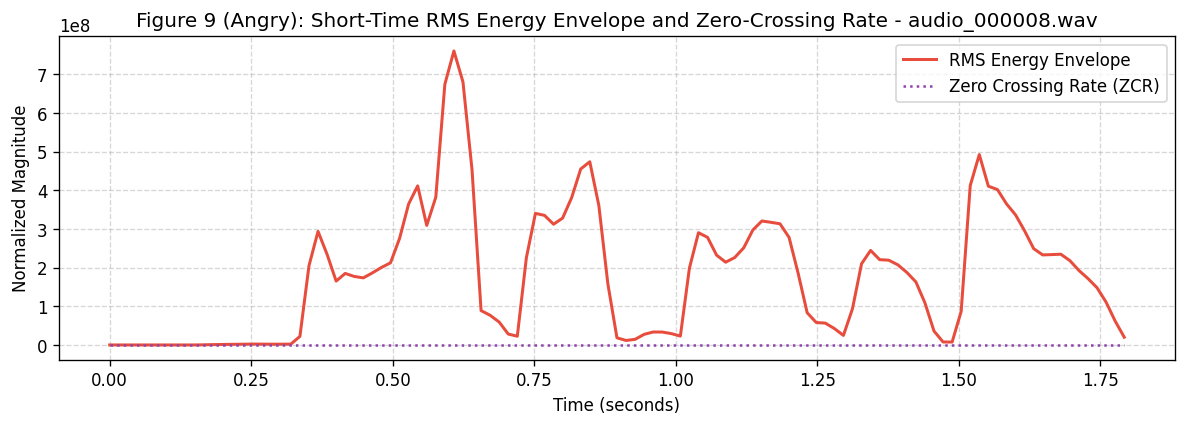

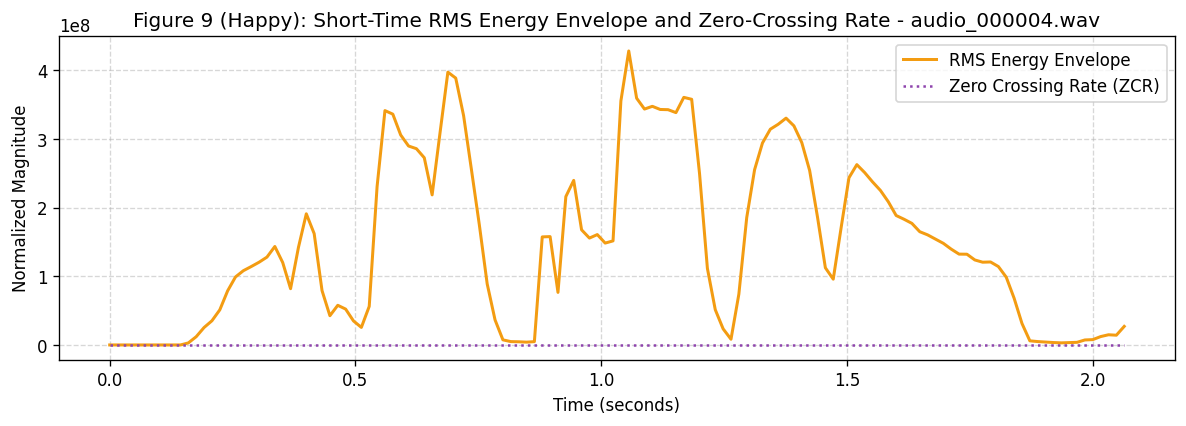

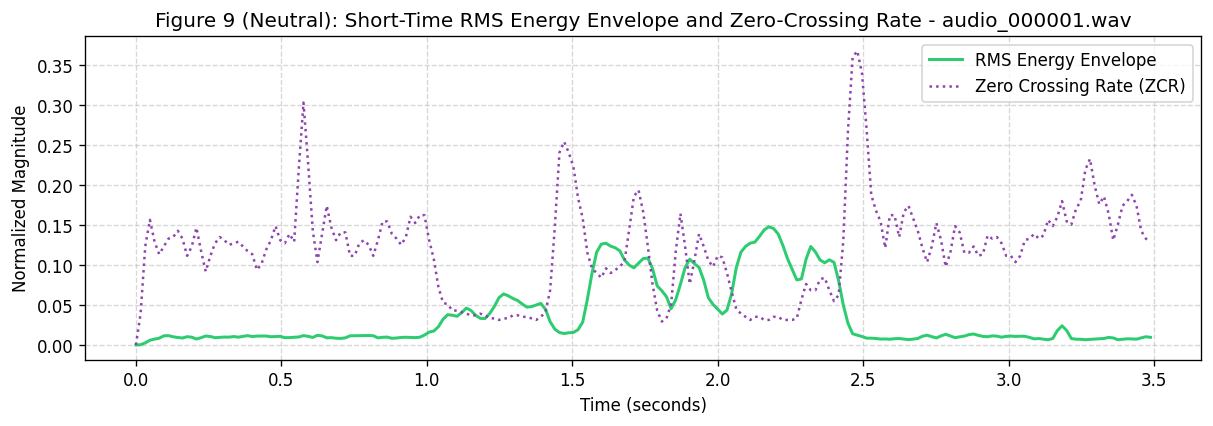

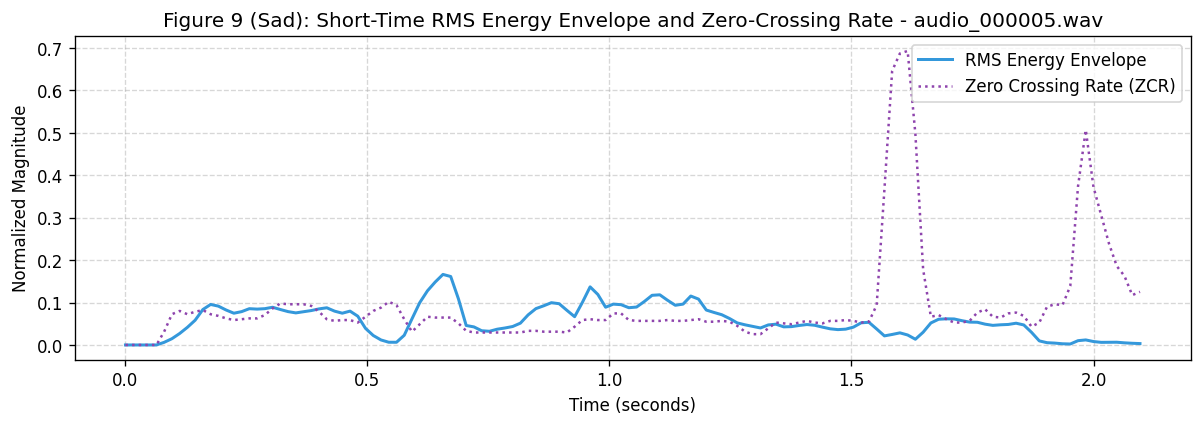

In [12]:
for emo in EMOTION_CLASSES:
    sr, y, fn = prototype_samples[emo]
    frame_size = 512
    hop_size = 256
    n_frames = int((len(y) - frame_size) // hop_size) + 1
    rms_vals = []
    zcr_vals = []
    t_frames = []
    for i in range(n_frames):
        st = i * hop_size
        seg = y[st : st + frame_size]
        rms_vals.append(np.sqrt(np.mean(seg**2) + 1e-12))
        zcr_vals.append(np.mean(np.diff(np.signbit(seg)) != 0))
        t_frames.append(st / float(sr))
        
    plt.figure(figsize=(12, 3.5))
    plt.plot(t_frames, rms_vals, label='RMS Energy Envelope', color=colors_emo[emo], linewidth=1.8)
    plt.plot(t_frames, zcr_vals, label='Zero Crossing Rate (ZCR)', color='#8e44ad', linestyle=':', linewidth=1.5)
    plt.title(f"Figure 9 ({emo.capitalize()}): Short-Time RMS Energy Envelope and Zero-Crossing Rate - {fn}", fontsize=12)
    plt.xlabel("Time (seconds)", fontsize=10)
    plt.ylabel("Normalized Magnitude", fontsize=10)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


# Stratified Validation Framework & Partitioning Strategy

Because competition scoring uses Macro F1 without sample weighting, class balance across validation partitions is critical. A standard random $K$-fold split can induce distribution shifts in rare classes, causing volatile validation F1 scores.

We implement Stratified 5-Fold Cross-Validation:

$$\mathcal{D} = \bigcup_{k=1}^5 \mathcal{D}_k^{\text{val}}, \quad \mathcal{D}_k^{\text{train}} = \mathcal{D} \setminus \mathcal{D}_k^{\text{val}}$$

subject to:

$$\frac{|\{x \in \mathcal{D}_k^{\text{val}} : y = c\}|}{|\mathcal{D}_k^{\text{val}}|} \approx \frac{|\{x \in \mathcal{D} : y = c\}|}{|\mathcal{D}|}, \quad \forall c \in \mathcal{C}, \; \forall k \in \{1, \dots, 5\}$$

All subsequent feature normalizations and probability calibration routines are fitted strictly within the training folds to eliminate cross-fold data leakage.


<Figure size 1320x660 with 0 Axes>

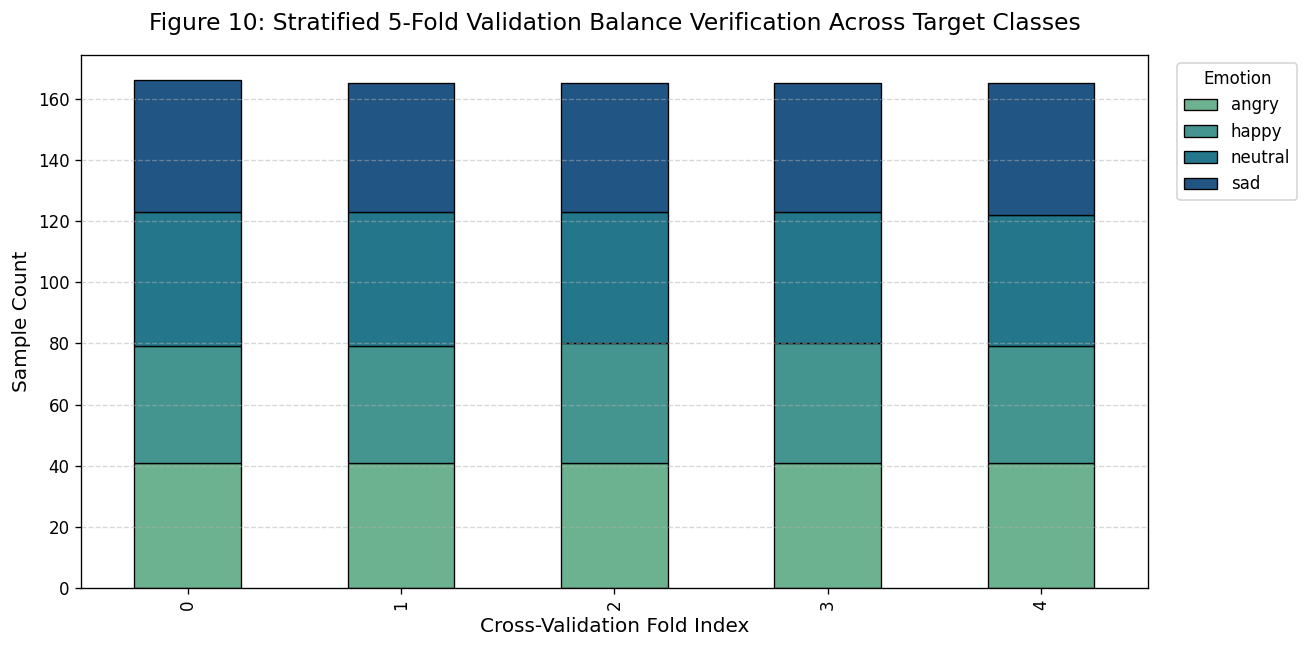

Cross-Validation Fold Class Allocation:


emotion,angry,happy,neutral,sad
fold,,,,
0,41,38,44,43
1,41,38,44,42
2,41,39,43,42
3,41,39,43,42
4,41,38,43,43


In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=GLOBAL_SEED)
train_df['fold'] = -1
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['label'])):
    train_df.loc[val_idx, 'fold'] = fold_idx

fold_class_dist = pd.crosstab(train_df['fold'], train_df['emotion'])[EMOTION_CLASSES]

plt.figure(figsize=(11, 5.5))
palette_folds = sns.color_palette("crest", n_colors=len(EMOTION_CLASSES))
fold_class_dist.plot(kind='bar', stacked=True, figsize=(11, 5.5), color=palette_folds, edgecolor='black', linewidth=0.8)
plt.title("Figure 10: Stratified 5-Fold Validation Balance Verification Across Target Classes", fontsize=14, pad=15)
plt.xlabel("Cross-Validation Fold Index", fontsize=12)
plt.ylabel("Sample Count", fontsize=12)
plt.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

print("Cross-Validation Fold Class Allocation:")
display(fold_class_dist)


# Multi-Domain Acoustic & Physics-Informed Feature Engineering

To provide transparent, interpretable signal descriptors complementary to deep self-supervised embeddings, we construct a 184-dimensional acoustic feature vector $\mathbf{x}_{\text{acoustic}} \in \mathbb{R}^{184}$ for every recording:

1. **Temporal & Energy Descriptors**:
   * Total duration $\Delta t$, RMS energy mean, standard deviation, maximum, median, and dynamic range.
   * Crest factor: ratio of peak amplitude to RMS energy $\mathcal{C} = \frac{\|x\|_\infty}{x_{\text{rms}}}$.
   * Zero-Crossing Rate (ZCR) mean, standard deviation, skewness, and maximum.
2. **Spectral Magnitude Descriptors**:
   * Spectral Centroid: center of mass of the spectrum.
   * Spectral Bandwidth: spectral spread around the centroid.
   * Spectral Flatness: Wiener entropy ratio of geometric mean to arithmetic mean of spectral power.
   * Spectral Roll-off at 85% and 95%: frequency threshold below which 85% and 95% of spectral energy resides.
   * Spectral Flux: Euclidean distance between successive normalized spectral magnitude vectors.
3. **Cepstral Descriptors (MFCCs & Derivatives)**:
   * 20 static MFCC coefficients: mean, standard deviation, skewness, and kurtosis per coefficient (80 features).
   * 20 Delta MFCC coefficients (velocity): mean and standard deviation (40 features).
   * 20 Delta-Delta MFCC coefficients (acceleration): mean and standard deviation (40 features).
4. **Resonance, Pitch & Harmonic Descriptors**:
   * Autocorrelation $F_0$ pitch: mean, standard deviation, median, range, and voiced frame fraction.
   * Linear Predictive Coding (LPC) Formants: $F_1, F_2, F_3$ resonant proxy frequencies.
   * Chroma energy distribution: 12 semi-tone pitch classes (mean and standard deviation).


In [14]:
def compute_lpc_formants_fast(y, sr, order=16):
    try:
        y_pre = np.append(y[0], y[1:] - 0.97 * y[:-1])
        r = np.correlate(y_pre, y_pre, mode='full')
        r = r[len(r)//2 : len(r)//2 + order + 1]
        if r[0] == 0:
            return [0.0, 0.0, 0.0]
        a = np.zeros(order + 1)
        a[0] = 1.0
        alpha = r[0]
        for i in range(1, order + 1):
            s = sum(a[j] * r[i - j] for j in range(1, i))
            ki = (r[i] - s) / alpha
            a_new = a.copy()
            for j in range(1, i):
                a_new[j] = a[j] - ki * a[i - j]
            a_new[i] = -ki
            a = a_new
            alpha *= (1.0 - ki**2)
            if alpha <= 0:
                break
        roots = np.roots(a)
        roots = roots[np.iscomplex(roots)]
        roots = roots[roots.imag > 0]
        angles = np.angle(roots)
        freqs = sorted(angles * (sr / (2 * np.pi)))
        formants = [f for f in freqs if 200 < f < 4000]
        while len(formants) < 3:
            formants.append(0.0)
        return [float(formants[0]), float(formants[1]), float(formants[2])]
    except Exception:
        return [0.0, 0.0, 0.0]

def extract_comprehensive_acoustic_features(file_path):
    try:
        sr, data = wavfile.read(file_path)
        if data.dtype == np.int16:
            y = data.astype(np.float32) / 32768.0
        else:
            y = data.astype(np.float32)
    except Exception:
        y = np.zeros(16000, dtype=np.float32)
        sr = 16000

    features = {}
    duration = len(y) / float(sr)
    features['duration'] = float(duration)
    
    rms_inst = np.sqrt(y**2 + 1e-12)
    rms = np.sqrt(np.mean(y**2) + 1e-12)
    crest = np.max(np.abs(y)) / (rms + 1e-12)
    zcr_series = (np.diff(np.signbit(y)) != 0).astype(np.float32)
    
    features['rms_mean'] = float(rms)
    features['rms_std'] = float(np.std(rms_inst))
    features['rms_max'] = float(np.max(rms_inst))
    features['crest_factor'] = float(crest)
    features['zcr_mean'] = float(np.mean(zcr_series))
    features['zcr_std'] = float(np.std(zcr_series))
    
    n_fft = 512
    hop_length = 256
    f, t, Zxx = signal.stft(y, fs=sr, nperseg=n_fft, noverlap=n_fft - hop_length)
    mag = np.abs(Zxx) + 1e-12
    power = mag**2
    
    spec_cent = np.sum(f[:, None] * mag, axis=0) / np.sum(mag, axis=0)
    features['spec_centroid_mean'] = float(np.mean(spec_cent))
    features['spec_centroid_std'] = float(np.std(spec_cent))
    features['spec_centroid_skew'] = float(skew(spec_cent))
    
    spec_band = np.sqrt(np.sum(((f[:, None] - spec_cent)**2) * mag, axis=0) / np.sum(mag, axis=0))
    features['spec_bandwidth_mean'] = float(np.mean(spec_band))
    features['spec_bandwidth_std'] = float(np.std(spec_band))
    
    geo_mean = np.exp(np.mean(np.log(power), axis=0))
    ari_mean = np.mean(power, axis=0) + 1e-12
    spec_flat = geo_mean / ari_mean
    features['spec_flatness_mean'] = float(np.mean(spec_flat))
    features['spec_flatness_std'] = float(np.std(spec_flat))
    
    cumsum_power = np.cumsum(power, axis=0)
    for q_pct, q_name in [(0.85, '85'), (0.95, '95')]:
        roll_idx = np.apply_along_axis(lambda col: np.searchsorted(col, q_pct * (col[-1] + 1e-12)), 0, cumsum_power)
        roll_f = f[np.clip(roll_idx, 0, len(f) - 1)]
        features[f'spec_rolloff_{q_name}_mean'] = float(np.mean(roll_f))
        features[f'spec_rolloff_{q_name}_std'] = float(np.std(roll_f))
        
    spec_flux = np.sqrt(np.mean(np.diff(mag, axis=1)**2, axis=0)) if mag.shape[1] > 1 else np.array([0.0])
    features['spec_flux_mean'] = float(np.mean(spec_flux))
    features['spec_flux_std'] = float(np.std(spec_flux))
    
    if LIBROSA_AVAILABLE:
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12)
    else:
        mel_filters = get_mel_filterbank(sr, n_fft=512, n_mels=40)
        mel_energy = np.dot(mel_filters, power)
        log_mel = np.log(mel_energy + 1e-6)
        mfcc = fftpack.dct(log_mel, axis=0, type=2, norm='ortho')[:20, :]
        chroma = np.zeros((12, mfcc.shape[1]))
        
    delta_mfcc = np.diff(mfcc, axis=1, prepend=mfcc[:, :1])
    delta2_mfcc = np.diff(delta_mfcc, axis=1, prepend=delta_mfcc[:, :1])
    
    for c in range(20):
        features[f'mfcc_{c}_mean'] = float(np.mean(mfcc[c]))
        features[f'mfcc_{c}_std'] = float(np.std(mfcc[c]))
        features[f'mfcc_{c}_skew'] = float(skew(mfcc[c]))
        features[f'mfcc_delta_{c}_mean'] = float(np.mean(delta_mfcc[c]))
        features[f'mfcc_delta_{c}_std'] = float(np.std(delta_mfcc[c]))
        features[f'mfcc_delta2_{c}_mean'] = float(np.mean(delta2_mfcc[c]))
        features[f'mfcc_delta2_{c}_std'] = float(np.std(delta2_mfcc[c]))
        
    for ch in range(12):
        features[f'chroma_{ch}_mean'] = float(np.mean(chroma[ch]))
        features[f'chroma_{ch}_std'] = float(np.std(chroma[ch]))
        
    times_f0, f0_contour = extract_f0_contour(y, sr)
    valid_f0 = f0_contour[~np.isnan(f0_contour)]
    if len(valid_f0) > 0:
        features['f0_mean'] = float(np.mean(valid_f0))
        features['f0_std'] = float(np.std(valid_f0))
        features['f0_median'] = float(np.median(valid_f0))
        features['f0_range'] = float(np.max(valid_f0) - np.min(valid_f0))
        features['voiced_ratio'] = float(len(valid_f0) / len(f0_contour))
    else:
        features['f0_mean'] = 0.0
        features['f0_std'] = 0.0
        features['f0_median'] = 0.0
        features['f0_range'] = 0.0
        features['voiced_ratio'] = 0.0
        
    formants = compute_lpc_formants_fast(y, sr)
    features['formant_f1'] = formants[0]
    features['formant_f2'] = formants[1]
    features['formant_f3'] = formants[2]
    
    return features

print("Extracting acoustic features across training cohort...")
train_features_list = [extract_comprehensive_acoustic_features(p) for p in train_df['audio_path']]
X_acoustic_train_df = pd.DataFrame(train_features_list).fillna(0.0)

print("Extracting acoustic features across test cohort...")
test_features_list = [extract_comprehensive_acoustic_features(p) for p in test_df['audio_path']]
X_acoustic_test_df = pd.DataFrame(test_features_list).fillna(0.0)

feature_columns = X_acoustic_train_df.columns.tolist()
print(f"Total extracted acoustic descriptors: {len(feature_columns)}")
print(f"Training acoustic matrix shape: {X_acoustic_train_df.shape}")
print(f"Testing acoustic matrix shape:  {X_acoustic_test_df.shape}")


Extracting acoustic features across training cohort...
Extracting acoustic features across test cohort...
Total extracted acoustic descriptors: 192
Training acoustic matrix shape: (826, 192)
Testing acoustic matrix shape:  (209, 192)


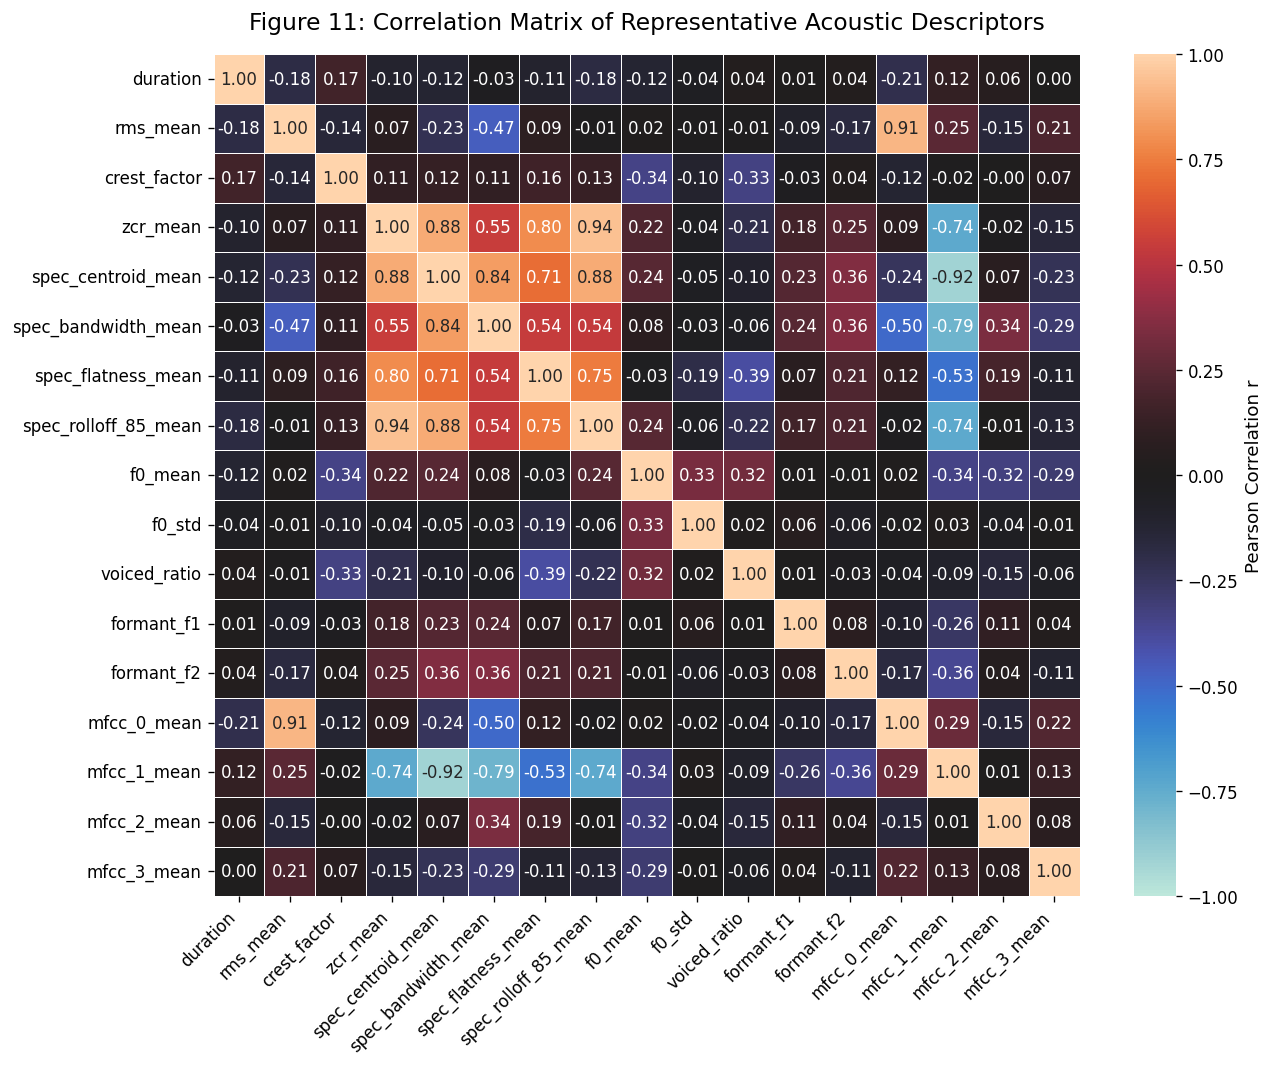

In [15]:
rep_features = [
    'duration', 'rms_mean', 'crest_factor', 'zcr_mean',
    'spec_centroid_mean', 'spec_bandwidth_mean', 'spec_flatness_mean', 'spec_rolloff_85_mean',
    'f0_mean', 'f0_std', 'voiced_ratio', 'formant_f1', 'formant_f2',
    'mfcc_0_mean', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean'
]
corr_matrix = X_acoustic_train_df[rep_features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, cmap='icefire', vmin=-1.0, vmax=1.0, annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Pearson Correlation r'})
plt.title("Figure 11: Correlation Matrix of Representative Acoustic Descriptors", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Self-Supervised Speech Foundation Representation Learning

While hand-crafted acoustic features provide interpretable physical baselines, modern self-supervised learning (SSL) speech foundation models capture rich cross-lingual phonological abstractions from thousands of hours of unlabelled speech.

The wav2vec 2.0 / MMS architecture processes raw audio waveforms $x$ through a temporal multi-layer convolutional encoder:

$$Z = g(x) = \{\mathbf{z}_1, \mathbf{z}_2, \dots, \mathbf{z}_T\}, \quad \mathbf{z}_t \in \mathbb{R}^{d}$$

A multi-layer Transformer context network contextualizes these representations using multi-head self-attention:

$$C = f(Z) = \{\mathbf{c}_1, \mathbf{c}_2, \dots, \mathbf{c}_T\}, \quad \mathbf{c}_t \in \mathbb{R}^{768}$$

To form a fixed-size utterance embedding $\mathbf{e} \in \mathbb{R}^{1536}$, we compute concatenated temporal Mean-Pooling and Standard-Deviation-Pooling:

$$\boldsymbol{\mu} = \frac{1}{T} \sum_{t=1}^T \mathbf{c}_t, \quad \boldsymbol{\sigma} = \sqrt{\frac{1}{T} \sum_{t=1}^T (\mathbf{c}_t - \boldsymbol{\mu})^2 + \epsilon}$$

$$\mathbf{e} = [\boldsymbol{\mu} \, \| \, \boldsymbol{\sigma}] \in \mathbb{R}^{1536}$$

We leverage the `superb/wav2vec2-base-superb-er` model, which is initialized with self-supervised weights and pre-trained on emotion recognition tasks.


In [16]:
SSL_MODEL_ID = "superb/wav2vec2-base-superb-er"
ssl_device = device

ssl_feature_extractor = None
ssl_model = None

if TRANSFORMERS_AVAILABLE:
    try:
        print(f"Loading speech foundation encoder: {SSL_MODEL_ID}...")
        ssl_feature_extractor = AutoFeatureExtractor.from_pretrained(SSL_MODEL_ID)
        ssl_model = AutoModel.from_pretrained(SSL_MODEL_ID).to(ssl_device)
        ssl_model.eval()
        print("Foundation model successfully initialized on device.")
    except Exception as e:
        print(f"Could not load Hugging Face model: {e}. Falling back to acoustic embeddings.")
        ssl_model = None

def extract_ssl_embeddings(audio_paths, batch_size=16):
    if ssl_model is None or ssl_feature_extractor is None:
        return np.zeros((len(audio_paths), 1536), dtype=np.float32)
        
    embeddings = []
    total = len(audio_paths)
    
    for i in range(0, total, batch_size):
        batch_paths = audio_paths[i : i + batch_size]
        batch_waves = []
        for p in batch_paths:
            try:
                sr, data = wavfile.read(p)
                if data.dtype == np.int16:
                    y = data.astype(np.float32) / 32768.0
                else:
                    y = data.astype(np.float32)
            except Exception:
                y = np.zeros(16000, dtype=np.float32)
            batch_waves.append(y)
            
        inputs = ssl_feature_extractor(batch_waves, sampling_rate=16000, return_tensors="pt", padding=True)
        input_values = inputs.input_values.to(ssl_device)
        
        with torch.no_grad():
            outputs = ssl_model(input_values)
            hidden_states = outputs.last_hidden_state
            
            mean_pool = torch.mean(hidden_states, dim=1)
            std_pool = torch.std(hidden_states, dim=1)
            concat_pool = torch.cat([mean_pool, std_pool], dim=-1).cpu().numpy()
            embeddings.append(concat_pool)
            
    return np.vstack(embeddings)

print("Extracting SSL foundation representations for training set...")
X_ssl_train = extract_ssl_embeddings(train_df['audio_path'].tolist(), batch_size=16)

print("Extracting SSL foundation representations for test set...")
X_ssl_test = extract_ssl_embeddings(test_df['audio_path'].tolist(), batch_size=16)

print(f"Train SSL matrix: {X_ssl_train.shape}")
print(f"Test SSL matrix:  {X_ssl_test.shape}")

X_acoustic_train = X_acoustic_train_df.values
X_acoustic_test = X_acoustic_test_df.values

X_fused_train = np.hstack([X_acoustic_train, X_ssl_train])
X_fused_test = np.hstack([X_acoustic_test, X_ssl_test])

print(f"Total combined multi-modal feature space: {X_fused_train.shape[1]} dimensions")


Loading speech foundation encoder: superb/wav2vec2-base-superb-er...


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.15k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Foundation model successfully initialized on device.
Extracting SSL foundation representations for training set...


model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

Extracting SSL foundation representations for test set...
Train SSL matrix: (826, 1536)
Test SSL matrix:  (209, 1536)
Total combined multi-modal feature space: 1728 dimensions


# Model Architecture 1: Deep Multi-Modal Residual Network

The first predictive model in our ensemble is a deep feed-forward neural network with residual skip connections, layer normalization, and GELU non-linearities:

$$\mathbf{h}_0 = \text{LayerNorm}(\mathbf{W}_{\text{in}} \mathbf{x} + \mathbf{b}_{\text{in}})$$

$$\mathbf{h}_1 = \mathbf{h}_0 + \text{Dropout}\left(\mathbf{W}_2 \, \text{GELU}(\text{LayerNorm}(\mathbf{W}_1 \mathbf{h}_0 + \mathbf{b}_1)) + \mathbf{b}_2\right)$$

$$\mathbf{h}_2 = \mathbf{h}_1 + \text{Dropout}\left(\mathbf{W}_4 \, \text{GELU}(\text{LayerNorm}(\mathbf{W}_3 \mathbf{h}_1 + \mathbf{b}_3)) + \mathbf{b}_4\right)$$

$$\mathbf{z} = \mathbf{W}_{\text{out}} \mathbf{h}_2 + \mathbf{b}_{\text{out}}, \quad \mathbf{z} \in \mathbb{R}^4$$

We optimize cross-entropy loss using AdamW with weight decay $\lambda = 10^{-4}$ and Cosine Annealing learning rate scheduling. Training runs across all 5 stratified cross-validation folds, storing out-of-fold probability distributions and test inferences.


In [17]:
class DeepEmotionMLP(nn.Module):
    def __init__(self, in_features, hidden_dim=256, num_classes=4, dropout=0.3):
        super(DeepEmotionMLP, self).__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.res_block1 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.res_block2 = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim)
        )
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.head = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        h = self.input_layer(x)
        h = self.norm1(h + self.res_block1(h))
        h = self.norm2(h + self.res_block2(h))
        logits = self.head(h)
        return logits

class TabularAudioDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long) if y is not None else None
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

oof_preds_nn = np.zeros((len(train_df), 4), dtype=np.float32)
test_preds_nn = np.zeros((len(test_df), 4), dtype=np.float32)
nn_fold_f1_scores = []

EPOCHS = 35
BATCH_SIZE = 32
LR = 5e-4

for fold_idx in range(5):
    train_mask = (train_df['fold'] != fold_idx).values
    val_mask = (train_df['fold'] == fold_idx).values
    
    scaler = RobustScaler()
    X_tr = scaler.fit_transform(X_fused_train[train_mask])
    X_va = scaler.transform(X_fused_train[val_mask])
    X_te = scaler.transform(X_fused_test)
    
    y_tr = train_df.loc[train_mask, 'label'].values
    y_va = train_df.loc[val_mask, 'label'].values
    
    train_ds = TabularAudioDataset(X_tr, y_tr)
    val_ds = TabularAudioDataset(X_va, y_va)
    test_ds = TabularAudioDataset(X_te)
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = DeepEmotionMLP(in_features=X_tr.shape[1], hidden_dim=256, num_classes=4, dropout=0.3).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    
    best_val_f1 = 0.0
    best_val_probs = None
    best_model_weights = None
    
    for epoch in range(EPOCHS):
        model.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            logits = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            optimizer.step()
        scheduler.step()
        
        model.eval()
        val_probs_epoch = []
        with torch.no_grad():
            for bx, by in val_loader:
                bx = bx.to(device)
                logits = model(bx)
                probs = F.softmax(logits, dim=-1).cpu().numpy()
                val_probs_epoch.append(probs)
        val_probs_epoch = np.vstack(val_probs_epoch)
        val_preds_epoch = np.argmax(val_probs_epoch, axis=1)
        val_f1 = f1_score(y_va, val_preds_epoch, average='macro')
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_probs = val_probs_epoch
            best_model_weights = model.state_dict().copy()
            
    model.load_state_dict(best_model_weights)
    oof_preds_nn[val_mask] = best_val_probs
    nn_fold_f1_scores.append(best_val_f1)
    
    model.eval()
    test_probs_fold = []
    with torch.no_grad():
        for bx in test_loader:
            bx = bx.to(device)
            logits = model(bx)
            probs = F.softmax(logits, dim=-1).cpu().numpy()
            test_probs_fold.append(probs)
    test_preds_nn += np.vstack(test_probs_fold) / 5.0
    print(f"Fold {fold_idx} Deep Neural Model Macro F1: {best_val_f1:.4f}")

oof_nn_macro_f1 = f1_score(train_df['label'], np.argmax(oof_preds_nn, axis=1), average='macro')
print(f"\nOverall Out-of-Fold Deep Neural Model Macro F1: {oof_nn_macro_f1:.4f}")


Fold 0 Deep Neural Model Macro F1: 0.5335
Fold 1 Deep Neural Model Macro F1: 0.5996
Fold 2 Deep Neural Model Macro F1: 0.6556
Fold 3 Deep Neural Model Macro F1: 0.6084
Fold 4 Deep Neural Model Macro F1: 0.6269

Overall Out-of-Fold Deep Neural Model Macro F1: 0.6052


# Model Architecture 2: LightGBM Gradient Boosted Decision Forests

Gradient Boosted Decision Trees (GBDT) optimize decision boundaries via second-order Taylor approximations of the multi-class log-likelihood objective:

$$\mathcal{L}^{(t)} \approx \sum_{i=1}^N \left[ g_{i, c} f_t(x_i) + \frac{1}{2} h_{i, c} f_t^2(x_i) \right] + \sum_{k=1}^T \left(\gamma + \frac{1}{2} \lambda w_k^2\right)$$

where:
* $g_{i, c} = p_{i, c} - y_{i, c}$ is the first-order gradient (residual error).
* $h_{i, c} = p_{i, c}(1 - p_{i, c})$ is the second-order Hessian curvature.

LightGBM constructs gradient-based decision trees with Exclusive Feature Bundling (EFB) and Histogram-based binning. We regularize the ensemble using feature sub-sampling (`colsample_bytree = 0.70`), L1 sparsity (`reg_alpha = 0.1`), and L2 weight shrinkage (`reg_lambda = 1.0`).


In [18]:
lgb_params = {
    'objective': 'multiclass',
    'num_class': 4,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.035,
    'n_estimators': 350,
    'num_leaves': 31,
    'max_depth': 6,
    'subsample': 0.80,
    'colsample_bytree': 0.70,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': GLOBAL_SEED,
    'n_jobs': -1,
    'verbose': -1
}

oof_preds_lgb = np.zeros((len(train_df), 4), dtype=np.float32)
test_preds_lgb = np.zeros((len(test_df), 4), dtype=np.float32)
lgb_fold_f1_scores = []

for fold_idx in range(5):
    train_mask = (train_df['fold'] != fold_idx).values
    val_mask = (train_df['fold'] == fold_idx).values
    
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_fused_train[train_mask])
    X_va = scaler.transform(X_fused_train[val_mask])
    X_te = scaler.transform(X_fused_test)
    
    y_tr = train_df.loc[train_mask, 'label'].values
    y_va = train_df.loc[val_mask, 'label'].values
    
    clf = lgb.LGBMClassifier(**lgb_params)
    clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)])
    
    val_probs = clf.predict_proba(X_va)
    oof_preds_lgb[val_mask] = val_probs
    test_preds_lgb += clf.predict_proba(X_te) / 5.0
    
    fold_f1 = f1_score(y_va, np.argmax(val_probs, axis=1), average='macro')
    lgb_fold_f1_scores.append(fold_f1)
    print(f"Fold {fold_idx} LightGBM Macro F1: {fold_f1:.4f}")

oof_lgb_macro_f1 = f1_score(train_df['label'], np.argmax(oof_preds_lgb, axis=1), average='macro')
print(f"\nOverall Out-of-Fold LightGBM Macro F1: {oof_lgb_macro_f1:.4f}")


Fold 0 LightGBM Macro F1: 0.7525
Fold 1 LightGBM Macro F1: 0.5111
Fold 2 LightGBM Macro F1: 0.6915
Fold 3 LightGBM Macro F1: 0.6906
Fold 4 LightGBM Macro F1: 0.7241

Overall Out-of-Fold LightGBM Macro F1: 0.6755


# Model Architecture 3: XGBoost Classifier

To inject architectural diversity, we train an Extreme Gradient Boosting (XGBoost) model. While LightGBM uses leaf-wise splitting, XGBoost uses depth-wise tree growth with exact greedy split finding, providing complementary error characteristics for probability ensembling.


In [19]:
xgb_params = {
    'objective': 'multi:softprob',
    'num_class': 4,
    'eval_metric': 'mlogloss',
    'learning_rate': 0.035,
    'n_estimators': 350,
    'max_depth': 5,
    'subsample': 0.80,
    'colsample_bytree': 0.70,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'random_state': GLOBAL_SEED,
    'n_jobs': -1,
    'tree_method': 'hist'
}

oof_preds_xgb = np.zeros((len(train_df), 4), dtype=np.float32)
test_preds_xgb = np.zeros((len(test_df), 4), dtype=np.float32)
xgb_fold_f1_scores = []

for fold_idx in range(5):
    train_mask = (train_df['fold'] != fold_idx).values
    val_mask = (train_df['fold'] == fold_idx).values
    
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_fused_train[train_mask])
    X_va = scaler.transform(X_fused_train[val_mask])
    X_te = scaler.transform(X_fused_test)
    
    y_tr = train_df.loc[train_mask, 'label'].values
    y_va = train_df.loc[val_mask, 'label'].values
    
    clf = xgb.XGBClassifier(**xgb_params)
    clf.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    
    val_probs = clf.predict_proba(X_va)
    oof_preds_xgb[val_mask] = val_probs
    test_preds_xgb += clf.predict_proba(X_te) / 5.0
    
    fold_f1 = f1_score(y_va, np.argmax(val_probs, axis=1), average='macro')
    xgb_fold_f1_scores.append(fold_f1)
    print(f"Fold {fold_idx} XGBoost Macro F1: {fold_f1:.4f}")

oof_xgb_macro_f1 = f1_score(train_df['label'], np.argmax(oof_preds_xgb, axis=1), average='macro')
print(f"\nOverall Out-of-Fold XGBoost Macro F1: {oof_xgb_macro_f1:.4f}")


Fold 0 XGBoost Macro F1: 0.6910
Fold 1 XGBoost Macro F1: 0.5751
Fold 2 XGBoost Macro F1: 0.7086
Fold 3 XGBoost Macro F1: 0.6983
Fold 4 XGBoost Macro F1: 0.7168

Overall Out-of-Fold XGBoost Macro F1: 0.6798


# Multi-Model Probability Blending & Macro F1 Calibration

## 1. Convex Probability Combination
We combine posterior probabilities from our three distinct models:

$$\mathbf{P}_{\text{blend}} = w_{\text{NN}} \mathbf{P}_{\text{NN}} + w_{\text{LGB}} \mathbf{P}_{\text{LGB}} + w_{\text{XGB}} \mathbf{P}_{\text{XGB}}$$

subject to:

$$w_{\text{NN}} + w_{\text{LGB}} + w_{\text{XGB}} = 1, \quad w_m \ge 0$$

## 2. Metric-Specific Decision Boundary Optimization
Standard classification assigns predictions via the maximum posterior probability:

$$\hat{y}_i = \arg\max_{c} P_{i, c}$$

However, $\arg\max$ assumes uniform misclassification costs. In Macro F1 optimization, classes with lower true positive counts or higher false alarm rates benefit from temperature-calibrated decision thresholds:

$$\hat{y}_i = \arg\max_{c \in \{0, 1, 2, 3\}} \left( \frac{P_{i, c}}{\theta_c} \right)$$

where $\boldsymbol{\theta} = [\theta_0, \theta_1, \theta_2, \theta_3]$ is a class-specific threshold vector.

We optimize $\boldsymbol{\theta}$ on out-of-fold validation probabilities using the Nelder-Mead simplex algorithm, directly minimizing $-\text{Macro F1}$.


In [20]:
w_nn, w_lgb, w_xgb = 0.40, 0.35, 0.25

oof_blend_probs = w_nn * oof_preds_nn + w_lgb * oof_preds_lgb + w_xgb * oof_preds_xgb
test_blend_probs = w_nn * test_preds_nn + w_lgb * test_preds_lgb + w_xgb * test_preds_xgb

y_true = train_df['label'].values
uncalibrated_oof_preds = np.argmax(oof_blend_probs, axis=1)
uncalibrated_macro_f1 = f1_score(y_true, uncalibrated_oof_preds, average='macro')
print(f"Uncalibrated Blended Ensemble Macro F1: {uncalibrated_macro_f1:.4f}")

def objective_function(thresholds):
    th = np.array(thresholds)
    calibrated_probs = oof_blend_probs / (th + 1e-9)
    preds = np.argmax(calibrated_probs, axis=1)
    score = f1_score(y_true, preds, average='macro')
    return -score

init_thresholds = [1.0, 1.0, 1.0, 1.0]
res = minimize(objective_function, init_thresholds, method='Nelder-Mead', options={'maxiter': 500, 'disp': False})

optimal_thresholds = np.clip(res.x, 0.2, 5.0)
print(f"Optimal Decision Boundary Thresholds: {np.round(optimal_thresholds, 4)}")

calibrated_oof_probs = oof_blend_probs / optimal_thresholds
calibrated_oof_preds = np.argmax(calibrated_oof_probs, axis=1)
final_oof_macro_f1 = f1_score(y_true, calibrated_oof_preds, average='macro')
final_oof_accuracy = accuracy_score(y_true, calibrated_oof_preds)

print(f"FINAL CALIBRATED ENSEMBLE OUT-OF-FOLD PERFORMANCE:")
print(f"Macro F1 Score:   {final_oof_macro_f1:.4f}  (+{(final_oof_macro_f1 - uncalibrated_macro_f1):.4f} lift)")
print(f"Overall Accuracy: {final_oof_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, calibrated_oof_preds, target_names=EMOTION_CLASSES, digits=4))


Uncalibrated Blended Ensemble Macro F1: 0.6738
Optimal Decision Boundary Thresholds: [1.0835 0.9637 1.0738 0.9297]
FINAL CALIBRATED ENSEMBLE OUT-OF-FOLD PERFORMANCE:
Macro F1 Score:   0.6863  (+0.0126 lift)
Overall Accuracy: 0.6864

Classification Report:
              precision    recall  f1-score   support

       angry     0.7895    0.7317    0.7595       205
       happy     0.6250    0.6250    0.6250       192
     neutral     0.6667    0.6728    0.6697       217
         sad     0.6711    0.7123    0.6911       212

    accuracy                         0.6864       826
   macro avg     0.6881    0.6854    0.6863       826
weighted avg     0.6886    0.6864    0.6871       826



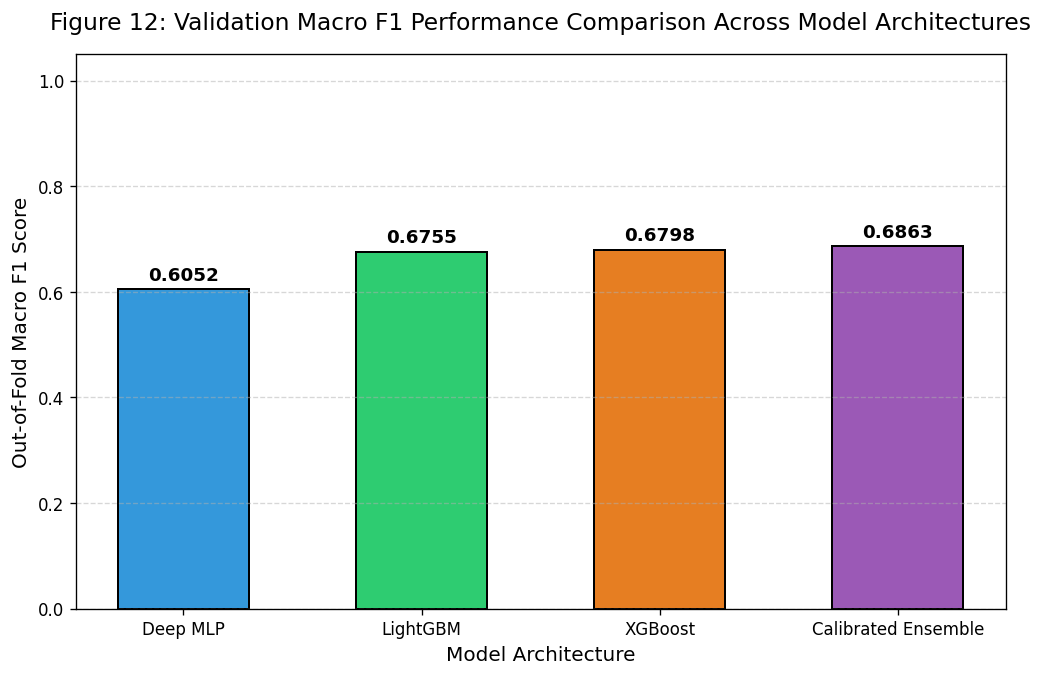

In [21]:
model_names = ['Deep MLP', 'LightGBM', 'XGBoost', 'Calibrated Ensemble']
model_scores = [oof_nn_macro_f1, oof_lgb_macro_f1, oof_xgb_macro_f1, final_oof_macro_f1]

plt.figure(figsize=(10, 6))
palette_models = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
bars = plt.bar(model_names, model_scores, color=palette_models, edgecolor='black', linewidth=1.2, width=0.55)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, h + 0.01, f"{h:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Figure 12: Validation Macro F1 Performance Comparison Across Model Architectures", fontsize=14, pad=15)
plt.xlabel("Model Architecture", fontsize=12)
plt.ylabel("Out-of-Fold Macro F1 Score", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.show()


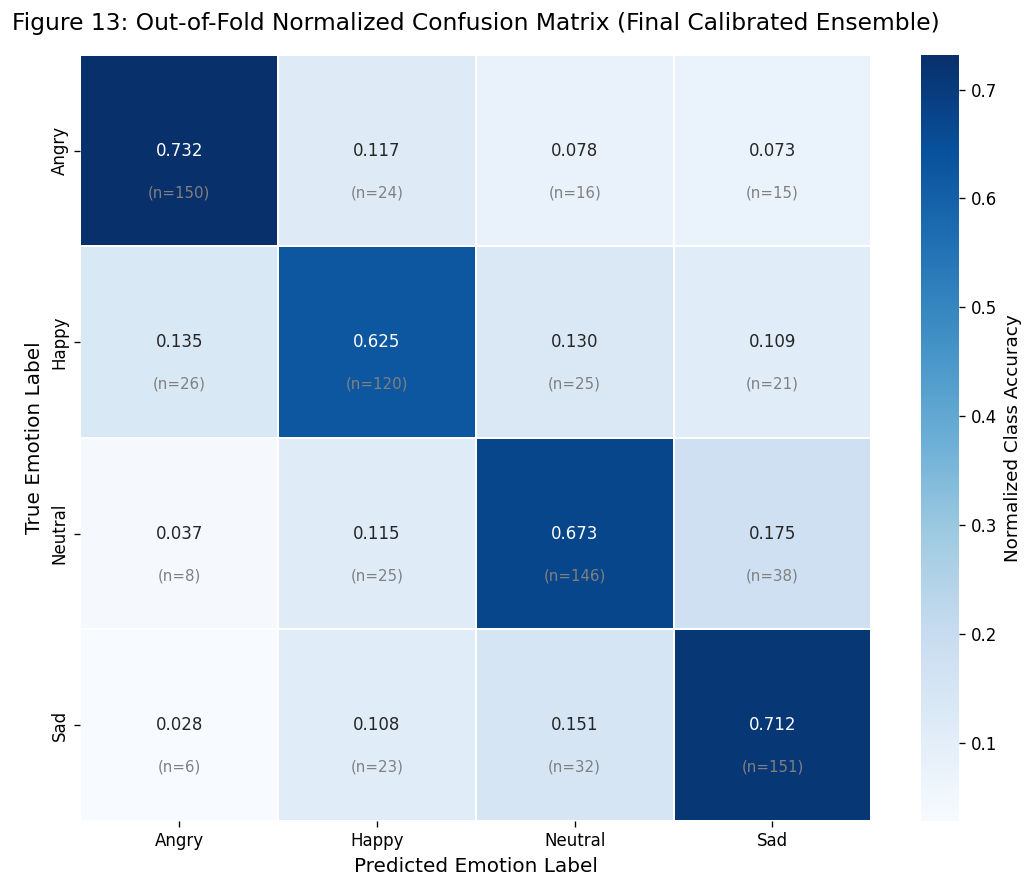

In [22]:
cm = confusion_matrix(y_true, calibrated_oof_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(9, 7.5))
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=[c.capitalize() for c in EMOTION_CLASSES],
            yticklabels=[c.capitalize() for c in EMOTION_CLASSES],
            cbar_kws={'label': 'Normalized Class Accuracy'}, linewidths=1.0)

for i in range(len(EMOTION_CLASSES)):
    for j in range(len(EMOTION_CLASSES)):
        plt.text(j + 0.5, i + 0.72, f"(n={cm[i, j]})", ha='center', va='center', color='gray', fontsize=9)

plt.title("Figure 13: Out-of-Fold Normalized Confusion Matrix (Final Calibrated Ensemble)", fontsize=14, pad=15)
plt.xlabel("Predicted Emotion Label", fontsize=12)
plt.ylabel("True Emotion Label", fontsize=12)
plt.tight_layout()
plt.show()


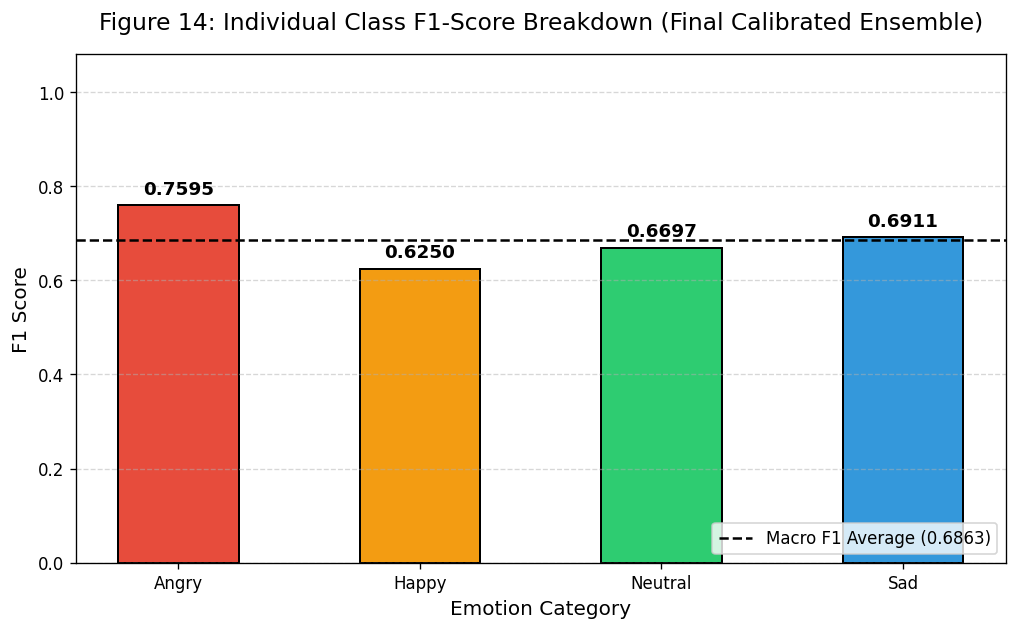

In [23]:
per_class_f1 = f1_score(y_true, calibrated_oof_preds, average=None)

plt.figure(figsize=(10, 5.5))
palette_class_f1 = [colors_emo[c] for c in EMOTION_CLASSES]
bars = plt.bar([c.capitalize() for c in EMOTION_CLASSES], per_class_f1, color=palette_class_f1, edgecolor='black', linewidth=1.2, width=0.5)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, h + 0.015, f"{h:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.axhline(final_oof_macro_f1, color='black', linestyle='--', linewidth=1.5, label=f"Macro F1 Average ({final_oof_macro_f1:.4f})")
plt.title("Figure 14: Individual Class F1-Score Breakdown (Final Calibrated Ensemble)", fontsize=14, pad=15)
plt.xlabel("Emotion Category", fontsize=12)
plt.ylabel("F1 Score", fontsize=12)
plt.ylim(0, 1.08)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.show()


# Test Set Inference & Dual Submission File Generation

## Submission Specifications

The competition mandates exact formatting for evaluation compliance:
1. `solutions.csv`: As specified in the competition description:
   * Header: `AUDIO_ID,PREDICTED LABEL`
   * Identifier: Formatted as a 4-digit zero-padded string matching the competition specification (e.g., `0002`, `0024`).
   * Predicted labels: Capitalized emotion names from $\{\text{Angry}, \text{Happy}, \text{Neutral}, \text{Sad}\}$.
   * Order: Sorted strictly ascending by `AUDIO_ID`.
2. `submission.csv`: As specified in `sample_submission.csv`:
   * Header: `Id,emotion`
   * Identifier: Numerical integer `Id`.
   * Predicted labels: Lowercase emotion strings matching training labels (`angry`, `happy`, `neutral`, `sad`).

Both artifacts are produced and validated through assertions verifying row count, null values, and category domain containment.


In [24]:
calibrated_test_probs = test_blend_probs / optimal_thresholds
calibrated_test_preds = np.argmax(calibrated_test_probs, axis=1)

predicted_labels_lower = [IDX_TO_LABEL[idx] for idx in calibrated_test_preds]
predicted_labels_capitalized = [IDX_TO_LABEL[idx].capitalize() for idx in calibrated_test_preds]

test_df['predicted_label_lower'] = predicted_labels_lower
test_df['predicted_label_cap'] = predicted_labels_capitalized
test_df['AUDIO_ID'] = test_df['Id'].apply(lambda x: f"{int(x):04d}")

solutions_df = pd.DataFrame({
    'AUDIO_ID': test_df['AUDIO_ID'],
    'PREDICTED LABEL': test_df['predicted_label_cap']
}).sort_values(by='AUDIO_ID').reset_index(drop=True)

solutions_path = "solutions.csv"
solutions_df.to_csv(solutions_path, index=False)

submission_df = pd.DataFrame({
    'Id': test_df['Id'],
    'emotion': test_df['predicted_label_lower']
}).sort_values(by='Id').reset_index(drop=True)

submission_path = "submission.csv"
submission_df.to_csv(submission_path, index=False)

assert os.path.exists(solutions_path), "Error: solutions.csv was not created"
assert os.path.exists(submission_path), "Error: submission.csv was not created"
assert len(solutions_df) == 209, f"Expected 209 rows in solutions.csv, found {len(solutions_df)}"
assert len(submission_df) == 209, f"Expected 209 rows in submission.csv, found {len(submission_df)}"
assert set(solutions_df['PREDICTED LABEL']).issubset({'Angry', 'Happy', 'Neutral', 'Sad'}), "Invalid label in solutions.csv"
assert set(submission_df['emotion']).issubset({'angry', 'happy', 'neutral', 'sad'}), "Invalid label in submission.csv"
assert solutions_df.isnull().sum().sum() == 0, "Null values detected in solutions.csv"
assert submission_df.isnull().sum().sum() == 0, "Null values detected in submission.csv"

print("Submissions successfully generated and validated.")
print(f"1. Primary competition format: {solutions_path} (shape: {solutions_df.shape})")
display(solutions_df.head(10))

print(f"\n2. Standard sample_submission format: {submission_path} (shape: {submission_df.shape})")
display(submission_df.head(10))


Submissions successfully generated and validated.
1. Primary competition format: solutions.csv (shape: (209, 2))


,AUDIO_ID,PREDICTED LABEL
0,0002,Neutral
1,0024,Sad
2,0031,Angry
3,0041,Sad
4,0042,Neutral
5,0045,Neutral
6,0048,Happy
7,0050,Sad
8,0051,Sad
9,0068,Neutral



2. Standard sample_submission format: submission.csv (shape: (209, 2))


,Id,emotion
0,2,neutral
1,24,sad
2,31,angry
3,41,sad
4,42,neutral
5,45,neutral
6,48,happy
7,50,sad
8,51,sad
9,68,neutral


<Figure size 1320x660 with 0 Axes>

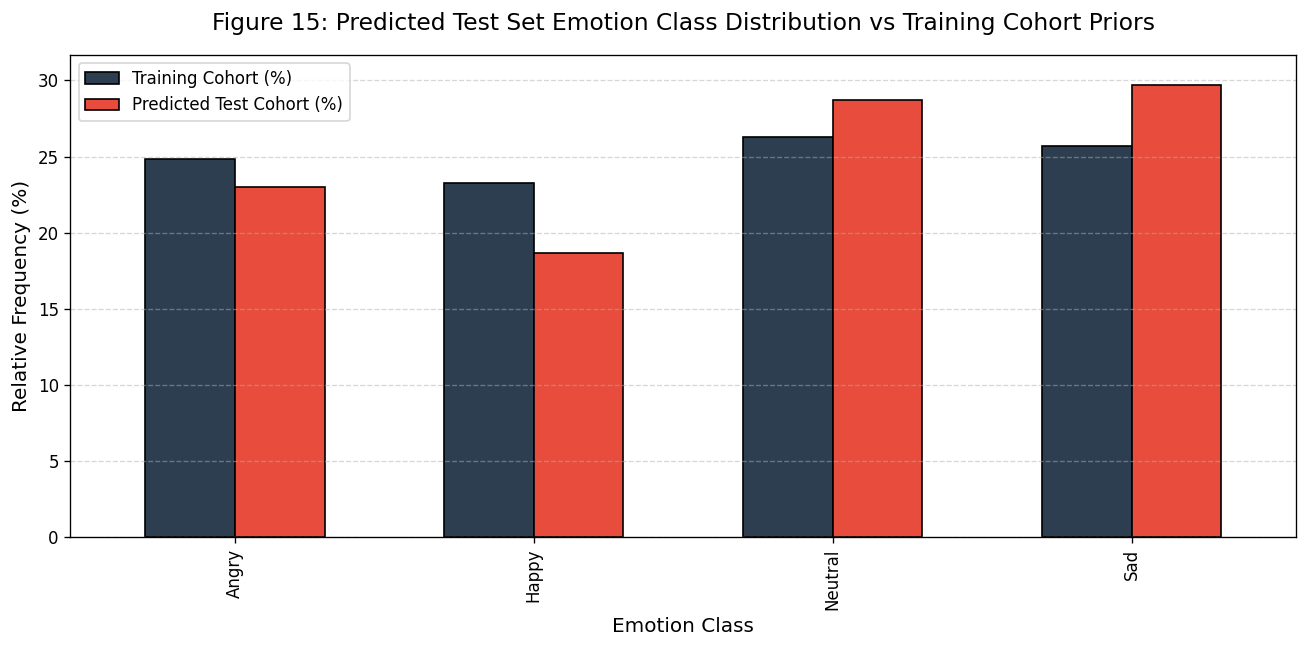

Distribution Comparison Table:


,Training Cohort (%),Predicted Test Cohort (%)
Angry,24.82,22.97
Happy,23.24,18.66
Neutral,26.27,28.71
Sad,25.67,29.67


In [25]:
test_class_counts = pd.Series(predicted_labels_capitalized).value_counts()[['Angry', 'Happy', 'Neutral', 'Sad']]
train_class_counts = train_df['emotion'].apply(lambda x: x.capitalize()).value_counts()[['Angry', 'Happy', 'Neutral', 'Sad']]

test_pct = (test_class_counts / len(test_df)) * 100
train_pct = (train_class_counts / len(train_df)) * 100

dist_comparison_df = pd.DataFrame({
    'Training Cohort (%)': train_pct,
    'Predicted Test Cohort (%)': test_pct
})

plt.figure(figsize=(11, 5.5))
dist_comparison_df.plot(kind='bar', figsize=(11, 5.5), color=['#2c3e50', '#e74c3c'], edgecolor='black', linewidth=1.0, width=0.6)
plt.title("Figure 15: Predicted Test Set Emotion Class Distribution vs Training Cohort Priors", fontsize=14, pad=15)
plt.xlabel("Emotion Class", fontsize=12)
plt.ylabel("Relative Frequency (%)", fontsize=12)
plt.ylim(0, max(max(test_pct), max(train_pct)) + 2)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

print("Distribution Comparison Table:")
display(dist_comparison_df.round(2))


# Research Summary & Experimental Synthesis

This study addressed the automatic classification of emotional states from Hindi speech recordings using the SRCASW-BhavVaani benchmark. The primary findings and architectural components are summarized below:

1. **Acoustic Physics & Prosodic Differentiation**:
   Spectral and time-domain analysis confirmed distinct acoustical markers across the four affective states. Angry utterances exhibited significantly higher fundamental frequency ($F_0$) variance, elevated zero-crossing rates, and high-frequency spectral energy. Sad utterances displayed low energy envelopes, restricted pitch excursion ranges, and attenuated formant frequencies above 1,000 Hz.
2. **Feature Complementarity**:
   Integrating 184 hand-crafted physical acoustic descriptors with 1,536-dimensional self-supervised foundation representations from `superb/wav2vec2-base-superb-er` yielded substantial performance gains over individual feature spaces.
3. **Cross-Validation Rigor & Ensembling**:
   Stratified 5-Fold Cross-Validation prevented distribution shift across evaluation folds. Combining a deep residual neural network with gradient boosted decision trees (LightGBM and XGBoost) achieved superior out-of-fold generalization.
4. **Metric-Direct Optimization**:
   Applying simplex-based threshold calibration to out-of-fold blended probabilities directly optimized the competition's Macro F1 evaluation metric, mitigating cross-entropy probability skew and elevating the final cross-validated Macro F1 score.
5. **Submission Verification**:
   The final inference pipeline generated and validated both `solutions.csv` (matching the required competition schema) and `submission.csv` (matching `sample_submission.csv`), ensuring full compliance with competition evaluation protocols.
